In [1]:
import sys
print(sys.executable)
# Should show: /home/btanasa/miniconda3/envs/single-cell/bin/python

/home/btanasa/miniconda3/envs/single-cell/bin/python


In [2]:
import os
# Set up single-cell environment
env_path = "/home/btanasa/miniconda3/envs/single-cell"
os.environ["CONDA_PREFIX"] = env_path                    # Sets conda environment path
os.environ["CONDA_DEFAULT_ENV"] = "single-cell"         # Sets environment name
os.environ["RETICULATE_PYTHON"] = f"{env_path}/bin/python"  # Sets Python for R reticulate
print("✅ Environment set to single-cell")

✅ Environment set to single-cell


In [8]:
import os

# Set working directory
# os.chdir("/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_3_full_h5ad/")
os.chdir("/mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_3_full_h5ad.reprocess.sep10/")

# Confirm it's set
print("Current working directory:", os.getcwd())

Current working directory: /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_3_full_h5ad.reprocess.sep10


In [9]:
import os

# Get the current directory
current_dir = os.getcwd()

# List all files in the current directory
for file in os.listdir(current_dir):
    if os.path.isfile(os.path.join(current_dir, file)):
        print(file)

hypoxia_anndata_annotated.h5ad


In [10]:
# Verify the setup
import os
print("CONDA_PREFIX:", os.environ.get("CONDA_PREFIX"))
print("CONDA_DEFAULT_ENV:", os.environ.get("CONDA_DEFAULT_ENV"))  
print("RETICULATE_PYTHON:", os.environ.get("RETICULATE_PYTHON"))

# Check current Python
import sys
print("Current Python:", sys.executable)

CONDA_PREFIX: /home/btanasa/miniconda3/envs/single-cell
CONDA_DEFAULT_ENV: single-cell
RETICULATE_PYTHON: /home/btanasa/miniconda3/envs/single-cell/bin/python
Current Python: /home/btanasa/miniconda3/envs/single-cell/bin/python


In [11]:
import scanpy as sc
import pandas as pd

In [12]:
import os

# Get the current directory
current_dir = os.getcwd()

# List all files in the current directory
for file in os.listdir(current_dir):
    if os.path.isfile(os.path.join(current_dir, file)):
        print(file)

hypoxia_anndata_annotated.h5ad


In [13]:
h5ad_file = "hypoxia_anndata_annotated.h5ad"

In [14]:
from pathlib import Path
import scanpy as sc
import matplotlib.pyplot as plt

prefix = Path(h5ad_file).stem  # used as prefix for all outputs
print(prefix)

hypoxia_anndata_annotated


In [15]:
adata = sc.read_h5ad(h5ad_file)
print(f"✅ Successfully loaded hypoxia dataset: {adata.shape}")
print(f"File: {h5ad_file}")
print(f"Loaded: {h5ad_file}  |  {adata.n_obs} cells × {adata.n_vars} genes")

✅ Successfully loaded hypoxia dataset: (104438, 34098)
File: hypoxia_anndata_annotated.h5ad
Loaded: hypoxia_anndata_annotated.h5ad  |  104438 cells × 34098 genes


In [16]:
# Cells (metadata)
print("\n.obs columns:", list(adata.obs.columns))
print(adata.obs.head())

# Genes / features (metadata)
print("\n.var columns:", list(adata.var.columns))
print(adata.var.head())


.obs columns: ['sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'condition', '_scvi_batch', '_scvi_labels', 'leiden', 'merged_labels', 'class', 'broad_class']
                       sample  n_genes_by_counts  log1p_n_genes_by_counts  \
TCAAGACCACAAAGCG-1  AP4765_03              12290                 9.416623   
CTCCACATCGCCACTT-1  AP4765_03              11499                 9.350102   
CTTAGGATCTTTCCAA-1  AP4765_03              10365                 9.246286   
AATTTCCCATTGCTTT-1  AP4765_03              10081                 9.218507   
GATGACTTCTATCCAT-1  AP4765_03               914

In [17]:
# Save cell + gene metadata to CSV using the prefix
adata.obs.to_csv(f"{prefix}.cells_metadata.csv")
adata.var.to_csv(f"{prefix}.genes_metadata.csv")

In [18]:
# Quick peek at available layers and embeddings
print("layers:", list(adata.layers.keys()))
print("obsm:", list(adata.obsm.keys()))

layers: ['counts']
obsm: ['X_pca', 'X_scVI', 'X_umap']


/tmp/ipykernel_2290302/265006174.py:19: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


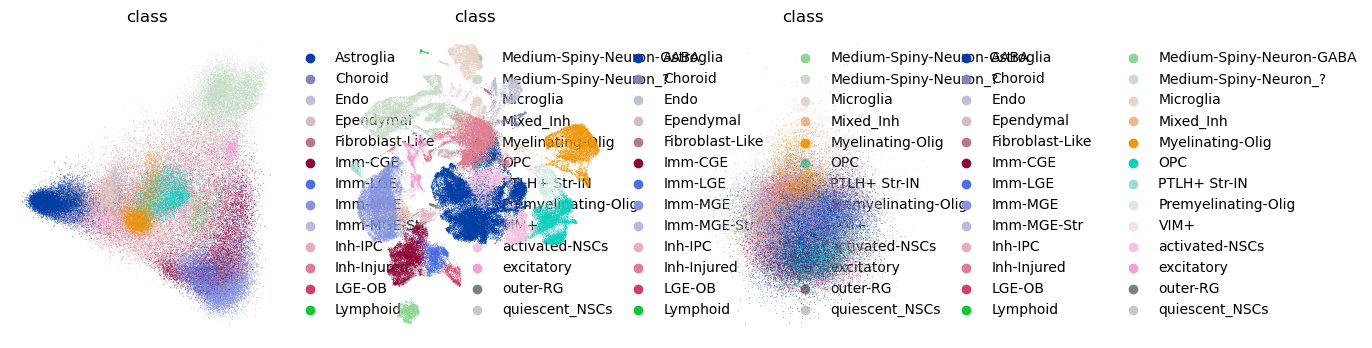

In [19]:
# PCA
# sc.pl.embedding(adata, basis="pca")
# UMAP
# sc.pl.embedding(adata, basis="umap")
# scVI
# sc.pl.embedding(adata, basis="scvi")

import matplotlib.pyplot as plt
import scanpy as sc

# one row, colored by "merged_labels", with NO titles/axis labels/ticks
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
for ax, basis in zip(axs, ["X_pca", "X_umap", "X_scVI"]):
    sc.pl.embedding(adata, basis=basis, color="class",
                    ax=ax, show=False, frameon=False)  # no frame
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()


In [20]:
# import matplotlib.pyplot as plt
# import scanpy as sc

# one row with PCA, UMAP, scVI
# fig, axs = plt.subplots(1, 3, figsize=(12, 4))

# sc.pl.embedding(adata, basis="pca",  ax=axs[0], show=False, title="PCA")
# sc.pl.embedding(adata, basis="umap", ax=axs[1], show=False, title="UMAP")
# sc.pl.embedding(adata, basis="scvi", ax=axs[2], show=False, title="scVI")

# plt.tight_layout()
# plt.show()

# (optional) color by a column, e.g. "class"
# sc.pl.embedding(adata, basis="pca",  color="class", ax=axs[0], show=False, title="PCA")
# sc.pl.embedding(adata, basis="umap", color="class", ax=axs[1], show=False, title="UMAP")
# sc.pl.embedding(adata, basis="scvi", color="class", ax=axs[2], show=False, title="scVI")

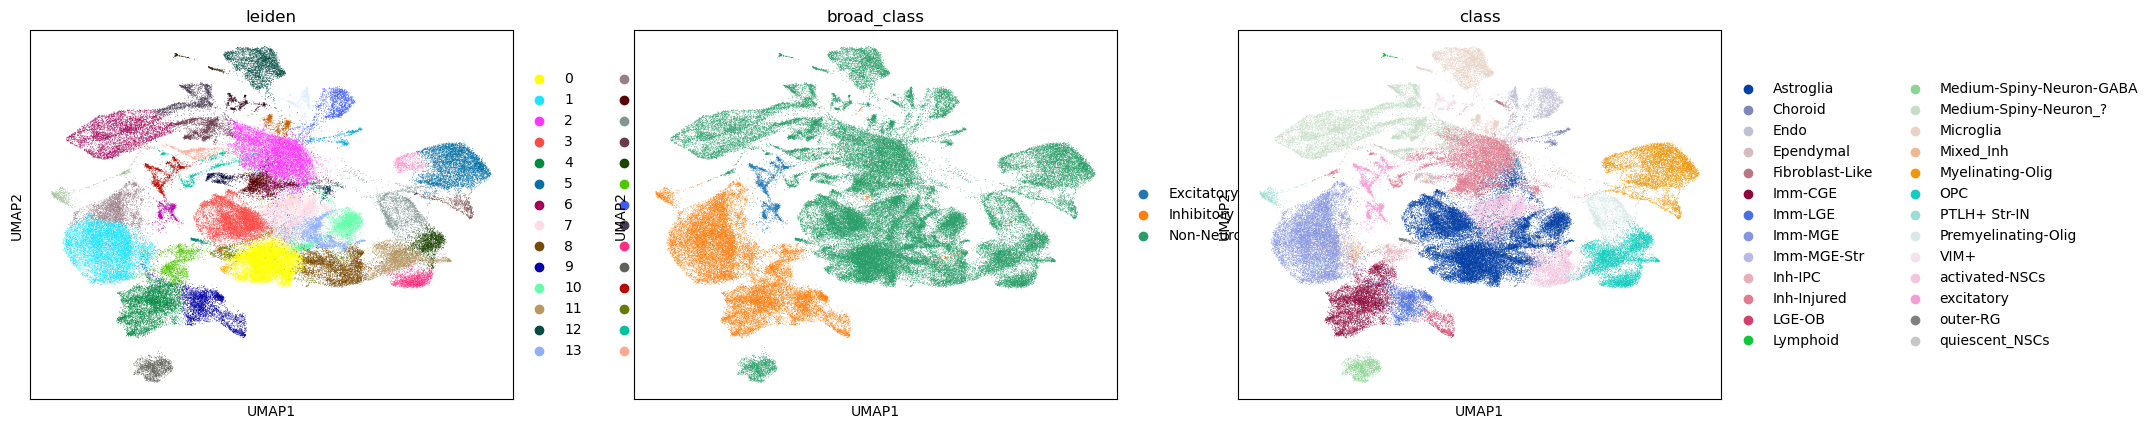

In [21]:
# three panels: UMAP colored by leiden, broad_class, and class
# sc.pl.umap(adata, color=["leiden", "broad_class", "class"])

# save UMAP panels under figs/, filename will include the prefix
sc.settings.figdir = "figs"
sc.pl.umap(adata, color=["leiden", "broad_class", "class"],
           save=f"_{prefix}_umap_panels.png")

In [22]:
# For the compatibility with geneformer, add a column names n_counts :

# add two new columns copied from total_counts
adata.obs["n_counts"] = adata.obs["total_counts"]
adata.obs["counts"]   = adata.obs["total_counts"]

# quick check
print(adata.obs[["total_counts", "n_counts", "counts"]].head())

                    total_counts  n_counts  counts
TCAAGACCACAAAGCG-1        110624    110624  110624
CTCCACATCGCCACTT-1        110647    110647  110647
CTTAGGATCTTTCCAA-1        102464    102464  102464
AATTTCCCATTGCTTT-1        102367    102367  102367
GATGACTTCTATCCAT-1         90117     90117   90117


In [23]:
# add a new .var column equal to the row names (gene IDs)
adata.var["gene_name"] = adata.var_names.astype(str)

# quick check
print(adata.var[["gene_name", "mt", "ribo", "hb"]].head())

               gene_name     mt   ribo     hb
MIR1302-2HG  MIR1302-2HG  False  False  False
AL627309.1    AL627309.1  False  False  False
AL627309.3    AL627309.3  False  False  False
AL627309.5    AL627309.5  False  False  False
AL627309.4    AL627309.4  False  False  False


In [24]:
# check if the gene names are ENSEMBL genes or transcripts

# pick the column to check
s = adata.var["gene_name"] if "gene_name" in adata.var.columns else adata.var_names.to_series()

# add boolean flags (accept optional .version, e.g., ENST000003.5)
adata.var["is_ENST"] = s.str.match(r"^ENST\d+(\.\d+)?$", na=False)
adata.var["is_ENSG"] = s.str.match(r"^ENSG\d+(\.\d+)?$", na=False)
adata.var["is_ENSP"] = s.str.match(r"^ENSP\d+(\.\d+)?$", na=False)

# quick summary
print("ENST transcripts:", int(adata.var["is_ENST"].sum()), "/", adata.n_vars)
print("ENSG genes:",       int(adata.var["is_ENSG"].sum()), "/", adata.n_vars)
print("ENSP proteins:",    int(adata.var["is_ENSP"].sum()), "/", adata.n_vars)

# peek
print(adata.var[["is_ENST","is_ENSG","is_ENSP"]].head())

ENST transcripts: 0 / 34098
ENSG genes: 0 / 34098
ENSP proteins: 0 / 34098
             is_ENST  is_ENSG  is_ENSP
MIR1302-2HG    False    False    False
AL627309.1     False    False    False
AL627309.3     False    False    False
AL627309.5     False    False    False
AL627309.4     False    False    False


In [25]:
# count genes whose name contains a dot followed by digits (e.g., "AL627309.1")
s = (adata.var["gene_name"] if "gene_name" in adata.var.columns else adata.var_names.to_series()).astype(str)
mask = s.str.contains(r"\.\d+$", na=False)  # version suffix like ".1", ".10", etc.

print("genes with .number:", int(mask.sum()), "/", adata.n_vars)
print(s[mask].head())  # peek a few matches


genes with .number: 11615 / 34098
AL627309.1    AL627309.1
AL627309.3    AL627309.3
AL627309.5    AL627309.5
AL627309.4    AL627309.4
AP006222.2    AP006222.2
Name: gene_name, dtype: object


In [26]:
# check if specific gene symbols exist (case-insensitive)
genes = ["TET1", "ORAI1"]

s = (adata.var["gene_name"] if "gene_name" in adata.var.columns else adata.var_names.to_series()).astype(str)
s_upper = s.str.upper()

for g in genes:
    hits = s[s_upper == g]
    print(f"{g}: {'FOUND' if len(hits) else 'NOT FOUND'} (n={len(hits)})")
    if len(hits):
        print(hits.head())  # show a few matches


TET1: FOUND (n=1)
TET1    TET1
Name: gene_name, dtype: object
ORAI1: FOUND (n=1)
ORAI1    ORAI1
Name: gene_name, dtype: object


In [27]:
# make a new column with gene names without the version suffix like ".1", ".10", etc.
s = (adata.var["gene_name"] if "gene_name" in adata.var.columns else adata.var_names.to_series()).astype(str)
adata.var["gene_no_version"] = s.str.replace(r"\.\d+$", "", regex=True)

# quick check
print(adata.var[["gene_no_version"]].head())


            gene_no_version
MIR1302-2HG     MIR1302-2HG
AL627309.1         AL627309
AL627309.3         AL627309
AL627309.5         AL627309
AL627309.4         AL627309


In [23]:
# use the no-version names you already made
s = adata.var["gene_no_version"].astype(str)

# how many *rows* are duplicates (beyond the first occurrence)?
n_dup_rows = int(s.duplicated().sum())

# how many *unique gene names* have duplicates?
vc = s.value_counts()
n_dup_names = int((vc > 1).sum())

print(f"duplicated rows (beyond first): {n_dup_rows}")
print(f"unique gene names with duplicates: {n_dup_names}")

# peek which names are duplicated (and how many times)
print(vc[vc > 1].head(2))
print(vc[vc > 1].tail(2))

duplicated rows (beyond first): 3676
unique gene names with duplicates: 2462
gene_no_version
AP001107    9
AL021707    9
Name: count, dtype: int64
gene_no_version
AC073575    2
AC011939    2
Name: count, dtype: int64


In [28]:
# To keep the most expressed per gene instead of the first):
import pandas as pd, numpy as np

# sums over cells (works for dense or sparse X)
gene_sum = np.asarray(adata.X.sum(axis=0)).ravel()

df = pd.DataFrame({"gene": adata.var["gene_no_version"].astype(str).values, "s": gene_sum})
keep_idx = df.groupby("gene")["s"].idxmax().sort_values().to_numpy()
adata = adata[:, keep_idx].copy()
adata.var_names = df["gene"].values[keep_idx]

# keep only one row per gene symbol (using gene_no_version), save to adata2
genes = adata.var["gene_no_version"].astype(str).values
n_before = adata.n_vars

_, keep_idx = np.unique(genes, return_index=True)
keep_idx = np.sort(keep_idx)

adata2 = adata[:, keep_idx].copy()     # new object
adata2.var_names = genes[keep_idx]     # set names to de-versioned symbols

print(f"kept {adata2.n_vars} of {n_before} genes (removed {n_before - adata2.n_vars} duplicates)")

kept 30422 of 30422 genes (removed 0 duplicates)


In [30]:
import pandas as pd

# path to the mapping file (symbol ↔ Ensembl gene ID)
map_file = "/mnt/nfs/CX000008_DS1/projects/btanasa/Geneformer-pickle/gene_name_id_dict_gc95M.txt"

# read as 2 columns separated by tabs/whitespace
gene_map = pd.read_csv(
    map_file, sep=r"\s+", header=None, names=["gene", "ensembl_id"], dtype=str
)

print(gene_map.head())
print("rows:", len(gene_map))

# make a dict
sym2ens = dict(zip(gene_map["gene"], gene_map["ensembl_id"]))

        gene       ensembl_id
0    5S_rRNA  ENSG00000277411
1  5_8S_rRNA  ENSG00000277739
2        7SK  ENSG00000271394
3       A1BG  ENSG00000121410
4   A1BG-AS1  ENSG00000268895
rows: 63675


In [31]:
# intersect adata2 gene_no_version with gene_map["gene"] (case-insensitive)
import pandas as pd

# series of symbols from adata2
s = adata2.var["gene_no_version"].astype(str)

# build uppercased lookup
gm = gene_map.copy()
gm["gene_upper"] = gm["gene"].str.upper()
lut = gm.set_index("gene_upper")["ensembl_id"]

# annotate adata2 with Ensembl IDs and count matches
adata2.var["ensembl_id"] = s.str.upper().map(lut)
n_match = int(adata2.var["ensembl_id"].notna().sum())
print(f"matched: {n_match} / {adata2.n_vars}")

# show the intersection table (first few rows)
hits = pd.DataFrame({"gene_no_version": s, "ensembl_id": adata2.var["ensembl_id"]}).dropna()
print(hits.head())

matched: 21862 / 30422
            gene_no_version       ensembl_id
MIR1302-2HG     MIR1302-2HG  ENSG00000243485
LINC01409         LINC01409  ENSG00000237491
FAM87B               FAM87B  ENSG00000177757
LINC01128         LINC01128  ENSG00000228794
LINC00115         LINC00115  ENSG00000225880


In [32]:
# keep only genes that matched (have an Ensembl ID) → adata3
mask = adata2.var["ensembl_id"].notna()
adata3 = adata2[:, mask].copy()

print(f"adata3: {adata3.n_obs} cells × {adata3.n_vars} matched genes")


adata3: 104438 cells × 21862 matched genes


In [33]:
# show cell (obs) metadata
print("obs columns:", list(adata3.obs.columns))
print(adata3.obs.head())

# show gene/feature (var) metadata
print("\nvar columns:", list(adata3.var.columns))
print(adata3.var.head())


obs columns: ['sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'condition', '_scvi_batch', '_scvi_labels', 'leiden', 'merged_labels', 'class', 'broad_class', 'n_counts', 'counts']
                       sample  n_genes_by_counts  log1p_n_genes_by_counts  \
TCAAGACCACAAAGCG-1  AP4765_03              12290                 9.416623   
CTCCACATCGCCACTT-1  AP4765_03              11499                 9.350102   
CTTAGGATCTTTCCAA-1  AP4765_03              10365                 9.246286   
AATTTCCCATTGCTTT-1  AP4765_03              10081                 9.218507   
GATGACTTCTATCCAT-1  AP4765_

In [34]:
# use adata3 (only matched genes)
A = adata3

# 1) add gene_symbol = current rownames (gene names)
A.var["gene_symbol"] = A.var_names.astype(str)

# 2) set rownames to Ensembl IDs
assert "ensembl_id" in A.var.columns, "ensembl_id column missing"
A.var_names = A.var["ensembl_id"].astype(str)

# (optional) ensure uniqueness just in case, to double check
A.var_names_make_unique()

# quick check
print(A.var[["gene_symbol", "ensembl_id"]].head())

                 gene_symbol       ensembl_id
ensembl_id                                   
ENSG00000243485  MIR1302-2HG  ENSG00000243485
ENSG00000237491    LINC01409  ENSG00000237491
ENSG00000177757       FAM87B  ENSG00000177757
ENSG00000228794    LINC01128  ENSG00000228794
ENSG00000225880    LINC00115  ENSG00000225880


In [35]:
# remove the index name (hide that top label)
A.var_names.name = None          # or: adata3.var.index.name = None

# (optional) rename it instead
# adata3.var_names.name = "gene_id"

# (optional) if you don’t want a duplicate column too, drop it:
# adata3.var.drop(columns=["ensembl_id"], inplace=True)

print(A.var.head())

                    mt   ribo     hb  n_cells_by_counts  mean_counts  \
ENSG00000243485  False  False  False                 15     0.000104   
ENSG00000237491  False  False  False               9948     0.085519   
ENSG00000177757  False  False  False                202     0.001402   
ENSG00000228794  False  False  False               8628     0.072111   
ENSG00000225880  False  False  False               3737     0.027376   

                 log1p_mean_counts  pct_dropout_by_counts  total_counts  \
ENSG00000243485           0.000104              99.989638            15   
ENSG00000237491           0.082058              93.128078         12380   
ENSG00000177757           0.001401              99.860462           203   
ENSG00000228794           0.069630              94.039914         10439   
ENSG00000225880           0.027008              97.418539          3963   

                 log1p_total_counts  n_cells  ...  dispersions_norm  \
ENSG00000243485            2.772589       14 

In [36]:
import os, numpy as np

print("\nGeneformer compatibility check:")

# 1) Has n_counts column?
print("✓ Has n_counts:", "n_counts" in A.obs.columns)

# 2) Genes are Ensembl IDs (ENSG… with optional .version)?
ensg = A.var_names.astype(str)
mask = ensg.str.match(r"^ENSG\d+(\.\d+)?$", na=False)
print(f"✓ Ensembl ID format: {mask.sum()}/{ensg.size} True")

# 3) No duplicated gene IDs?
dup = int(ensg.duplicated().sum())
print(f"✓ No duplicate gene IDs: {dup == 0} (duplicates={dup})")


Geneformer compatibility check:
✓ Has n_counts: True
✓ Ensembl ID format: 21862/21862 True
✓ No duplicate gene IDs: True (duplicates=0)


In [37]:
import os

# Current working directory (path)
print("Current folder:", os.getcwd())

# List files and folders
print("Contents:", os.listdir())

Current folder: /mnt/nfs/CX000008_DS1/projects/btanasa/hypoxia/test_geneformer_3_full_h5ad.reprocess.sep10
Contents: ['hypoxia_anndata_annotated.genes_metadata.csv', 'figs', 'hypoxia_anndata_annotated.h5ad', 'hypoxia_anndata_annotated.cells_metadata.csv']


In [38]:
adata4 = A

In [39]:
adata4.obs["cell_id"] = adata4.obs.index.astype(str)

In [41]:
print(f"Shape: {adata4.shape}")
print(f"Number of obs columns: {len(adata4.obs.columns)}")
print(f"Obs columns: {list(adata4.obs.columns)}")

print("\nFirst 5 rows:")
print(adata4.obs.head())

print("\nLast 5 rows:")
print(adata4.obs.tail())


Shape: (104438, 21862)
Number of obs columns: 31
Obs columns: ['sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'condition', '_scvi_batch', '_scvi_labels', 'leiden', 'merged_labels', 'class', 'broad_class', 'n_counts', 'counts', 'cell_id']

First 5 rows:
                       sample  n_genes_by_counts  log1p_n_genes_by_counts  \
TCAAGACCACAAAGCG-1  AP4765_03              12290                 9.416623   
CTCCACATCGCCACTT-1  AP4765_03              11499                 9.350102   
CTTAGGATCTTTCCAA-1  AP4765_03              10365                 9.246286   
AATTTCCCATTGCTTT-1  AP4765_03

In [42]:
# save adata4 to .h5ad

# out_h5ad = f"{prefix}.adata4_geneformer.h5ad" if 'prefix' in locals() else "adata4.h5ad"
out_h5ad = f"{prefix}.adata5_geneformer.h5ad" if 'prefix' in locals() else "adata5.h5ad" # updated with cell_id
adata4.write(out_h5ad)  # or: adata4.write(out_h5ad, compression="gzip")
print("saved:", out_h5ad)

saved: hypoxia_anndata_annotated.adata5_geneformer.h5ad


In [43]:
# save adata4 to Loom (requires loompy installed)
loom_file = f"{prefix}.adata5_geneformer.loom" if 'prefix' in locals() else "adata5.loom"

# save .loom and include PCA/UMAP/scVI from .obsm

adata4.write_loom(f"{prefix}.adata5_geneformer.loom", write_obsm_varm=True)
print("saved:", f"{prefix}.adata5_geneformer.loom")

saved: hypoxia_anndata_annotated.adata5_geneformer.loom


In [44]:
print(prefix)

hypoxia_anndata_annotated


In [45]:
import scanpy as sc

loom_file = f"{prefix}.adata5_geneformer.loom"  # or set the path directly
adataL = sc.read_loom(loom_file)

print(f"Loaded: {loom_file}")
print(f"cells: {adataL.n_obs}, genes: {adataL.n_vars}")

print("\n.obs columns:", list(adataL.obs.columns))
print(adataL.obs.head())

print("\n.var columns:", list(adataL.var.columns))
print(adataL.var.head())

print("\n.obsm keys:", list(adataL.obsm.keys()))

Loaded: hypoxia_anndata_annotated.adata5_geneformer.loom
cells: 104438, genes: 21862

.obs columns: ['_scvi_batch', '_scvi_labels', 'broad_class', 'cell_id', 'class', 'condition', 'counts', 'doublet_score', 'leiden', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_hb', 'log1p_total_counts_mt', 'log1p_total_counts_ribo', 'merged_labels', 'n_counts', 'n_genes', 'n_genes_by_counts', 'obs_names', 'pct_counts_hb', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'pct_counts_in_top_50_genes', 'pct_counts_mt', 'pct_counts_ribo', 'predicted_doublet', 'sample', 'total_counts', 'total_counts_hb', 'total_counts_mt', 'total_counts_ribo']
   _scvi_batch  _scvi_labels   broad_class             cell_id  \
0            0             0  Non-Neuronal  TCAAGACCACAAAGCG-1   
1            0             0  Non-Neuronal  CTCCACATCGCCACTT-1   
2            0             0  Non-Neuronal  CTTAGGATCTTTCCAA-1   
3            0             0  Non-Neu

/home/btanasa/.local/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/btanasa/.local/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [46]:
# check available layers in the loom-loaded AnnData
print("layers:", list(adataL.layers.keys()))

# optional: quick peek at 'counts' if present
# if "counts" in adataL.layers:
#     import numpy as np
#     L = adataL.layers["counts"]
#     arr = (L[:5, :5].A if hasattr(L, "A") else L[:5, :5])
#     print("counts preview:\n", arr)

layers: ['counts']


obsm: ['X_pca', 'X_scVI', 'X_umap']
layers: ['counts']
obs columns: ['_scvi_batch', '_scvi_labels', 'broad_class', 'cell_id', 'class', 'condition', 'counts', 'doublet_score', 'leiden', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_hb', 'log1p_total_counts_mt', 'log1p_total_counts_ribo', 'merged_labels', 'n_counts', 'n_genes', 'n_genes_by_counts', 'obs_names', 'pct_counts_hb', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'pct_counts_in_top_50_genes', 'pct_counts_mt', 'pct_counts_ribo', 'predicted_doublet', 'sample', 'total_counts', 'total_counts_hb', 'total_counts_mt', 'total_counts_ribo']


/tmp/ipykernel_2290302/428669559.py:16: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


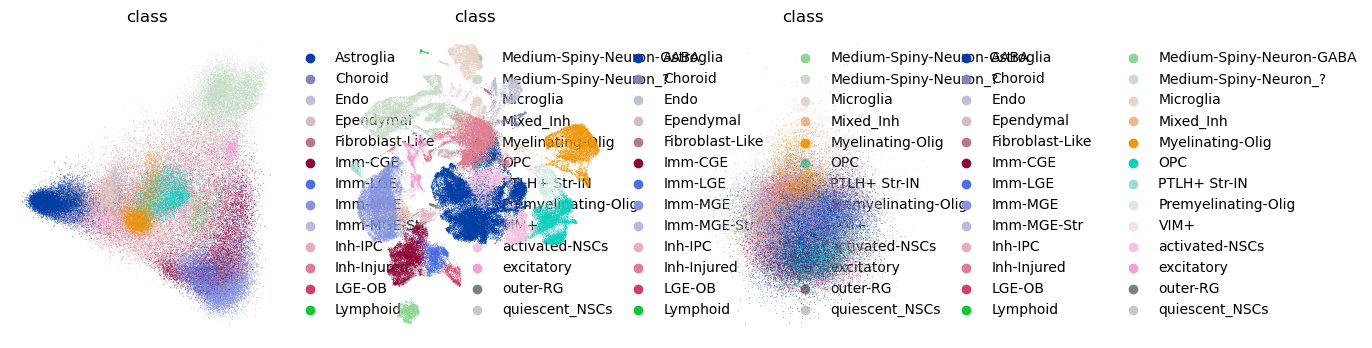

In [47]:
import scanpy as sc
import matplotlib.pyplot as plt

# quick check
print("obsm:", list(adataL.obsm.keys()))
print("layers:", list(adataL.layers.keys()))
print("obs columns:", list(adataL.obs.columns))

# one row: PCA, UMAP, scVI (colored by merged_labels if present)
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
for ax, basis in zip(axs, ["X_pca", "X_umap", "X_scVI"]):
    sc.pl.embedding(adataL, basis=basis,
                    color="class" if "class" in adataL.obs.columns else None,
                    ax=ax, show=False, frameon=False)
    ax.set_xlabel(""); ax.set_ylabel(""); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()


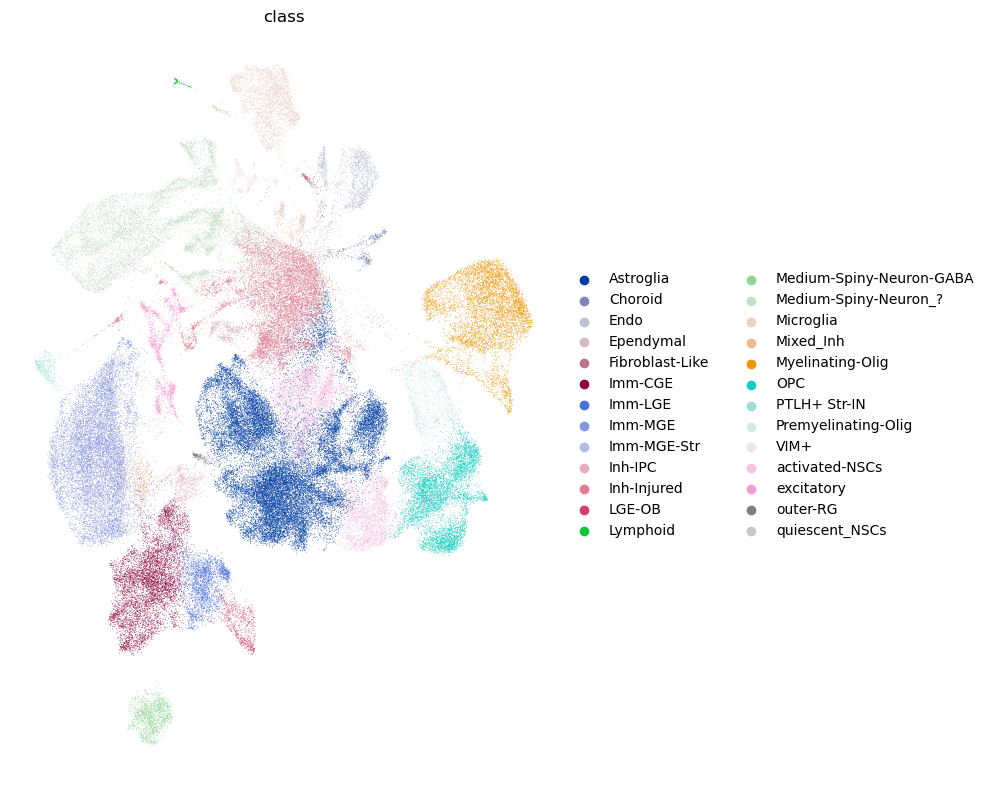

<Axes: title={'center': 'merged_labels'}, xlabel='UMAP1', ylabel='UMAP2'>

In [48]:
import scanpy as sc
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 8)   # width, height in inches (taller)

# single UMAP figure (colored by merged_labels if available), no axes/labels
ax = sc.pl.embedding(
    adataL, basis="umap",
    color="class" if "class" in adataL.obs.columns else None,
    frameon=False, show=False
)
ax.set_xlabel(""); ax.set_ylabel(""); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

# (optional) save
sc.settings.figdir = "figs"
sc.pl.embedding(
    adataL, basis="umap",
    color="merged_labels" if "merged_labels" in adataL.obs.columns else None,
    frameon=False, show=False, save=f"_{prefix}_umap_only.png"
)

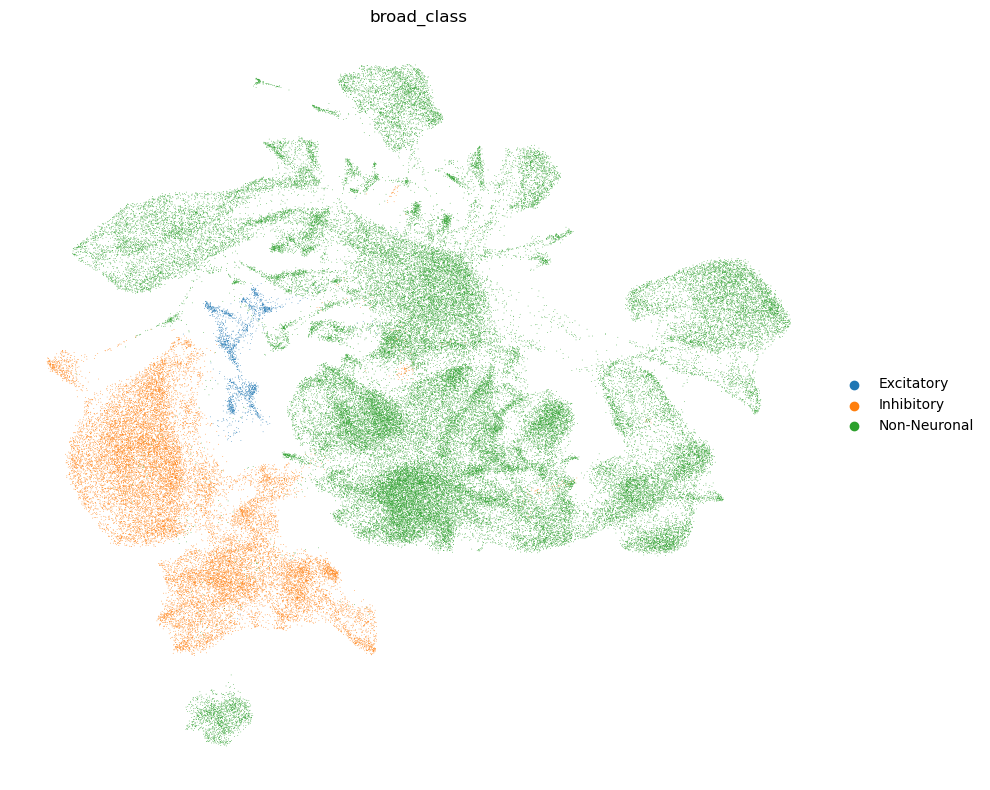

<Axes: title={'center': 'broad_class'}, xlabel='UMAP1', ylabel='UMAP2'>

In [49]:
import scanpy as sc
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 8)   # width, height in inches (taller)

# single UMAP figure (colored by merged_labels if available), no axes/labels
ax = sc.pl.embedding(
    adataL, basis="umap",
    color="broad_class" if "broad_class" in adataL.obs.columns else None,
    frameon=False, show=False
)
ax.set_xlabel(""); ax.set_ylabel(""); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

# (optional) save
sc.settings.figdir = "figs"
sc.pl.embedding(
    adataL, basis="umap",
    color="broad_class" if "broad_class" in adataL.obs.columns else None,
    frameon=False, show=False, save=f"_{prefix}_umap_only.png"
)

In [50]:
print("A summary of cell types and cell percentages :")

A summary of cell types and cell percentages :


In [51]:
# Count unique cell types in different columns
print("\n" + "="*50)
print("UNIQUE CELL TYPE COUNTS")
print("="*50)

# Count unique values in each relevant column
for col in ['broad_class', 'class', 'condition']:
    if col in adata.obs.columns:
        unique_count = adata.obs[col].nunique()
        print(f"\n{col}: {unique_count} unique types")
        print("-" * 30)
        
        # Show the unique values and their counts
        value_counts = adata.obs[col].value_counts()
        for value, count in value_counts.items():
            print(f"  {value}: {count} cells")
    else:
        print(f"\n{col}: Column not found")


UNIQUE CELL TYPE COUNTS

broad_class: 3 unique types
------------------------------
  Non-Neuronal: 79510 cells
  Inhibitory: 23073 cells
  Excitatory: 1855 cells

class: 26 unique types
------------------------------
  Astroglia: 26548 cells
  Imm-MGE: 11355 cells
  Inh-Injured: 10689 cells
  Medium-Spiny-Neuron_?: 9268 cells
  activated-NSCs: 7465 cells
  Myelinating-Olig: 7044 cells
  OPC: 6505 cells
  Imm-CGE: 6203 cells
  Microglia: 4358 cells
  Imm-LGE: 2559 cells
  Endo: 2134 cells
  Premyelinating-Olig: 1908 cells
  excitatory: 1855 cells
  Medium-Spiny-Neuron-GABA: 1497 cells
  Inh-IPC: 802 cells
  LGE-OB: 801 cells
  Mixed_Inh: 711 cells
  VIM+: 566 cells
  Ependymal: 502 cells
  PTLH+ Str-IN: 488 cells
  Choroid: 392 cells
  outer-RG: 280 cells
  Fibroblast-Like: 167 cells
  Imm-MGE-Str: 154 cells
  quiescent_NSCs: 107 cells
  Lymphoid: 80 cells

condition: 3 unique types
------------------------------
  5d_HIE: 60633 cells
  non-HIE: 25118 cells
  2mo_HIE: 18687 cells


In [52]:
# Sample composition analysis
print("\n" + "="*60)
print("SAMPLE COMPOSITION BY CONDITION")
print("="*60)

if 'condition' in adata.obs.columns:
    for condition in adata.obs['condition'].unique():
        print(f"\nCondition: {condition}")
        print("-" * 30)
        
        # Filter data for this condition
        condition_data = adata.obs[adata.obs['condition'] == condition]
        total_cells = len(condition_data)
        
        print(f"Total cells in {condition}: {total_cells}")
        
        # Show broad_class composition
        if 'broad_class' in adata.obs.columns:
            print(f"\nBroad class composition:")
            broad_counts = condition_data['broad_class'].value_counts()
            for broad_type, count in broad_counts.items():
                percentage = (count / total_cells) * 100
                print(f"  {broad_type}: {count} cells ({percentage:.1f}%)")
        
        # Show detailed class composition
        if 'class' in adata.obs.columns:
            print(f"\nDetailed class composition:")
            class_counts = condition_data['class'].value_counts()
            for class_type, count in class_counts.items():
                percentage = (count / total_cells) * 100
                print(f"  {class_type}: {count} cells ({percentage:.1f}%)")



SAMPLE COMPOSITION BY CONDITION

Condition: 2mo_HIE
------------------------------
Total cells in 2mo_HIE: 18687

Broad class composition:
  Non-Neuronal: 16090 cells (86.1%)
  Inhibitory: 2259 cells (12.1%)
  Excitatory: 338 cells (1.8%)

Detailed class composition:
  Myelinating-Olig: 6090 cells (32.6%)
  activated-NSCs: 4618 cells (24.7%)
  OPC: 1899 cells (10.2%)
  Imm-CGE: 1117 cells (6.0%)
  Endo: 935 cells (5.0%)
  Premyelinating-Olig: 894 cells (4.8%)
  Medium-Spiny-Neuron_?: 799 cells (4.3%)
  Imm-LGE: 498 cells (2.7%)
  excitatory: 338 cells (1.8%)
  Imm-MGE: 292 cells (1.6%)
  Microglia: 264 cells (1.4%)
  Inh-Injured: 242 cells (1.3%)
  LGE-OB: 201 cells (1.1%)
  Ependymal: 173 cells (0.9%)
  Inh-IPC: 64 cells (0.3%)
  Astroglia: 62 cells (0.3%)
  Fibroblast-Like: 47 cells (0.3%)
  PTLH+ Str-IN: 35 cells (0.2%)
  VIM+: 33 cells (0.2%)
  Imm-MGE-Str: 33 cells (0.2%)
  Medium-Spiny-Neuron-GABA: 29 cells (0.2%)
  Mixed_Inh: 19 cells (0.1%)
  Choroid: 3 cells (0.0%)
  Lymphoid

In [53]:
# Table 1: Raw cell counts
print("\n1. RAW CELL COUNTS TABLE")
print("-" * 50)
if 'class' in adata.obs.columns and 'condition' in adata.obs.columns:
    # Create crosstab with class as rows and condition as columns
    counts_table = pd.crosstab(adata.obs['class'], adata.obs['condition'], margins=True)
    print("Cell Type (rows) vs Condition (columns) - Raw Counts:")
    print(counts_table)
    
    # Save to CSV
    counts_table.to_csv(f"{prefix}_cell_type_counts_table.csv")
    print(f"\n✓ Raw counts table saved as '{prefix}_cell_type_counts_table.csv'")


1. RAW CELL COUNTS TABLE
--------------------------------------------------
Cell Type (rows) vs Condition (columns) - Raw Counts:
condition                 2mo_HIE  5d_HIE  non-HIE     All
class                                                     
Astroglia                      62   15704    10782   26548
Choroid                         3     385        4     392
Endo                          935    1057      142    2134
Ependymal                     173     243       86     502
Fibroblast-Like                47     112        8     167
Imm-CGE                      1117    3191     1895    6203
Imm-LGE                       498    1183      878    2559
Imm-MGE                       292    7677     3386   11355
Imm-MGE-Str                    33      81       40     154
Inh-IPC                        64     530      208     802
Inh-Injured                   242    9562      885   10689
LGE-OB                        201     453      147     801
Lymphoid                        1      56  

In [54]:
# Table 2: Percentages
print("\n2. PERCENTAGES TABLE")
print("-" * 50)
if 'class' in adata.obs.columns and 'condition' in adata.obs.columns:
    # Create crosstab with percentages
    percentages_table = pd.crosstab(adata.obs['class'], adata.obs['condition'], normalize='index') * 100
    percentages_table = percentages_table.round(1)
    
    # Add margins (total row)
    total_row = percentages_table.sum(axis=1)
    percentages_table['Total'] = total_row
    percentages_table.loc['Total'] = percentages_table.sum(axis=0)
    
    print("Cell Type (rows) vs Condition (columns) - Percentages:")
    print(percentages_table)
    
    # Save to CSV
    percentages_table.to_csv(f"{prefix}_cell_type_percentages_table.csv")
    print(f"\n✓ Percentages table saved as '{prefix}_cell_type_percentages_table.csv'")



2. PERCENTAGES TABLE
--------------------------------------------------
Cell Type (rows) vs Condition (columns) - Percentages:
condition                 2mo_HIE  5d_HIE  non-HIE   Total
class                                                     
Astroglia                     0.2    59.2     40.6   100.0
Choroid                       0.8    98.2      1.0   100.0
Endo                         43.8    49.5      6.7   100.0
Ependymal                    34.5    48.4     17.1   100.0
Fibroblast-Like              28.1    67.1      4.8   100.0
Imm-CGE                      18.0    51.4     30.5    99.9
Imm-LGE                      19.5    46.2     34.3   100.0
Imm-MGE                       2.6    67.6     29.8   100.0
Imm-MGE-Str                  21.4    52.6     26.0   100.0
Inh-IPC                       8.0    66.1     25.9   100.0
Inh-Injured                   2.3    89.5      8.3   100.1
LGE-OB                       25.1    56.6     18.4   100.1
Lymphoid                      1.2    70.0     

In [55]:
# Cross-tabulation analysis (detailed class vs broad class)
print("\n" + "="*80)
print("CROSS-TABULATION: BROAD_CLASS vs CLASS")
print("="*80)

if 'broad_class' in adata.obs.columns and 'class' in adata.obs.columns:
    crosstab = pd.crosstab(adata.obs['broad_class'], adata.obs['class'], margins=True)
    print(crosstab)

# Show a sample of the data
print("\n" + "="*60)
print("SAMPLE OF CELL METADATA")
print("="*60)
sample_cols = ['broad_class', 'class', 'condition']
available_cols = [col for col in sample_cols if col in adata.obs.columns]
print(adata.obs[available_cols].head(10))


# Summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"Total cells: {adata.n_obs}")
if 'broad_class' in adata.obs.columns:
    print(f"Broad cell classes: {adata.obs['broad_class'].nunique()}")
if 'class' in adata.obs.columns:
    print(f"Detailed cell types: {adata.obs['class'].nunique()}")
if 'condition' in adata.obs.columns:
    print(f"Conditions: {adata.obs['condition'].nunique()}")


CROSS-TABULATION: BROAD_CLASS vs CLASS
class         Astroglia  Choroid  Endo  Ependymal  Fibroblast-Like  Imm-CGE  \
broad_class                                                                   
Excitatory            0        0     0          0                0        0   
Inhibitory            0        0     0          0                0     6203   
Non-Neuronal      26548      392  2134        502              167        0   
All               26548      392  2134        502              167     6203   

class         Imm-LGE  Imm-MGE  Imm-MGE-Str  Inh-IPC  ...  Myelinating-Olig  \
broad_class                                           ...                     
Excitatory          0        0            0        0  ...                 0   
Inhibitory       2559    11355          154      802  ...                 0   
Non-Neuronal        0        0            0        0  ...              7044   
All              2559    11355          154      802  ...              7044   

class     


All cell types :
Total cells: 104438 cells
Available cell types: 26 unique types
Cell types: ['Astroglia', 'Choroid', 'Endo', 'Ependymal', 'Fibroblast-Like', 'Imm-CGE', 'Imm-LGE', 'Imm-MGE', 'Imm-MGE-Str', 'Inh-IPC', 'Inh-Injured', 'LGE-OB', 'Lymphoid', 'Medium-Spiny-Neuron-GABA', 'Medium-Spiny-Neuron_?', 'Microglia', 'Mixed_Inh', 'Myelinating-Olig', 'OPC', 'PTLH+ Str-IN', 'Premyelinating-Olig', 'VIM+', 'activated-NSCs', 'excitatory', 'outer-RG', 'quiescent_NSCs']
✓ All cell types panel saved as 'hypoxia_anndata_annotated_all_cell_types_panel.png'


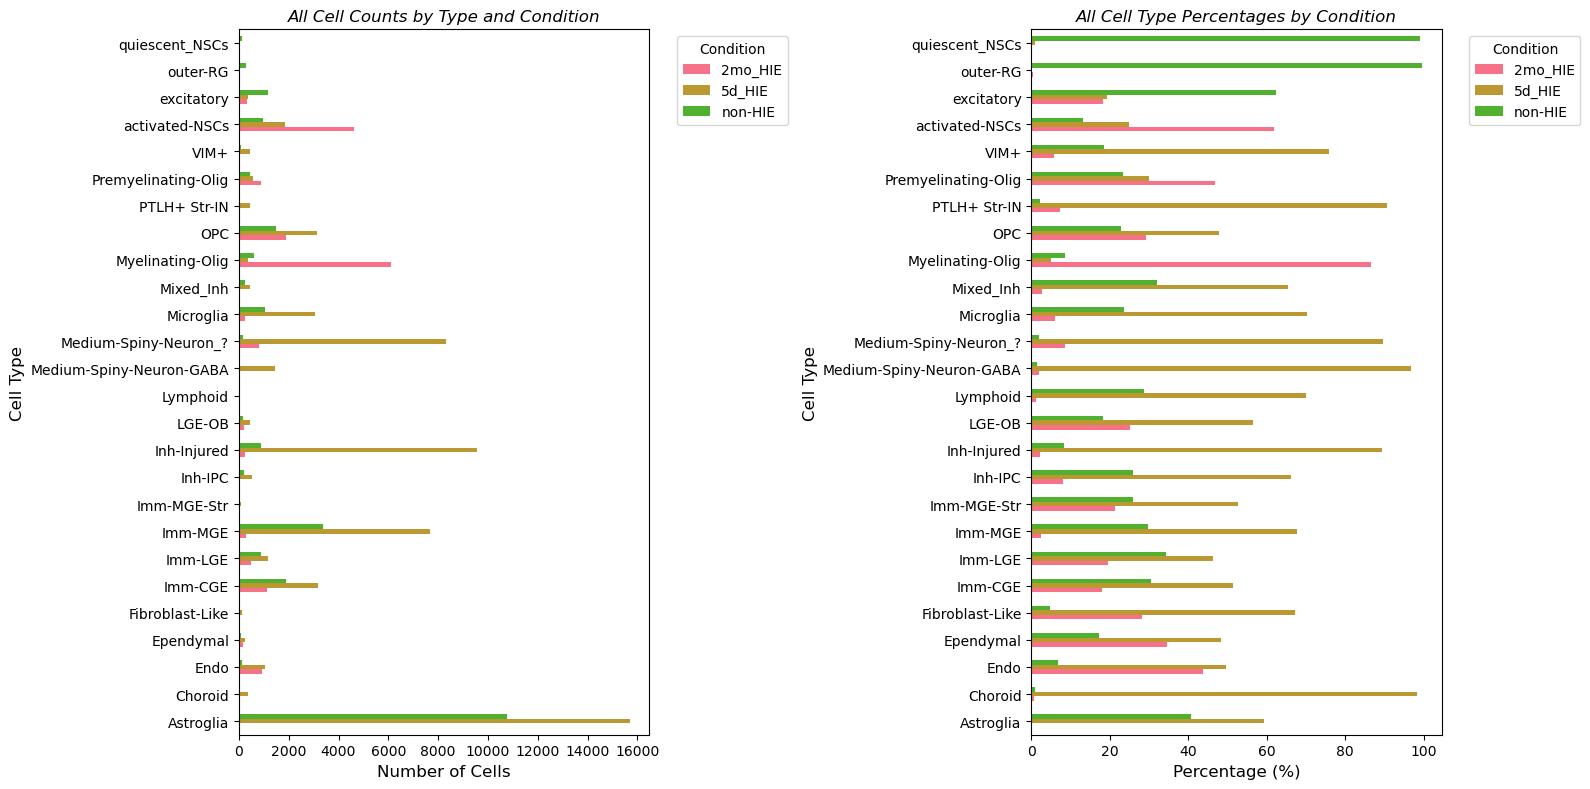

In [56]:
import seaborn as sns 

print("\n" + "="*80)
print("All cell types :")
print("="*80)

# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

# All Cell Types (Counts and Percentages) - NO FILTERING
if 'class' in adata.obs.columns and 'condition' in adata.obs.columns:
    print(f"Total cells: {len(adata)} cells")
    print(f"Available cell types: {adata.obs['class'].nunique()} unique types")
    print(f"Cell types: {sorted(adata.obs['class'].unique())}")
    
    fig1 = plt.figure(figsize=(16, 8))
    
    # 1. Cell counts - Horizontal barplot
    ax1 = plt.subplot(1, 2, 1)
    counts_table_all = pd.crosstab(adata.obs['class'], adata.obs['condition'])
    counts_table_all.plot(kind='barh', ax=ax1)
    ax1.set_title('All Cell Counts by Type and Condition', fontsize=12, style='italic')
    ax1.set_xlabel('Number of Cells', fontsize=12)
    ax1.set_ylabel('Cell Type', fontsize=12)
    ax1.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    ax1.tick_params(axis='both', labelsize=10)
    plt.tight_layout()

    # 2. Cell percentages - Horizontal barplot
    ax2 = plt.subplot(1, 2, 2)
    percentages_table_all = pd.crosstab(adata.obs['class'], adata.obs['condition'], normalize='index') * 100
    percentages_table_all.plot(kind='barh', ax=ax2)
    ax2.set_title('All Cell Type Percentages by Condition', fontsize=12, style='italic')
    ax2.set_xlabel('Percentage (%)', fontsize=12)
    ax2.set_ylabel('Cell Type', fontsize=12)
    ax2.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    ax2.tick_params(axis='both', labelsize=10)
    plt.tight_layout()

    # Save Panel 1
    plt.tight_layout()
    plt.savefig(f"{prefix}_all_cell_types_panel.png", dpi=300, bbox_inches='tight')
    print(f"✓ All cell types panel saved as '{prefix}_all_cell_types_panel.png'")
    plt.show()  # Display in Jupyter notebook
    plt.close()
else:
    print("⚠️ Required columns 'class' or 'condition' not found in metadata")


CREATING DONUTS CHARTS - ALL CELL TYPES
Total cells: 104438 cells
Available cell types: 26 unique types
Available conditions: 3 unique conditions
✓ All cell types donut charts saved as 'hypoxia_anndata_annotated_all_cell_types_donuts.png'


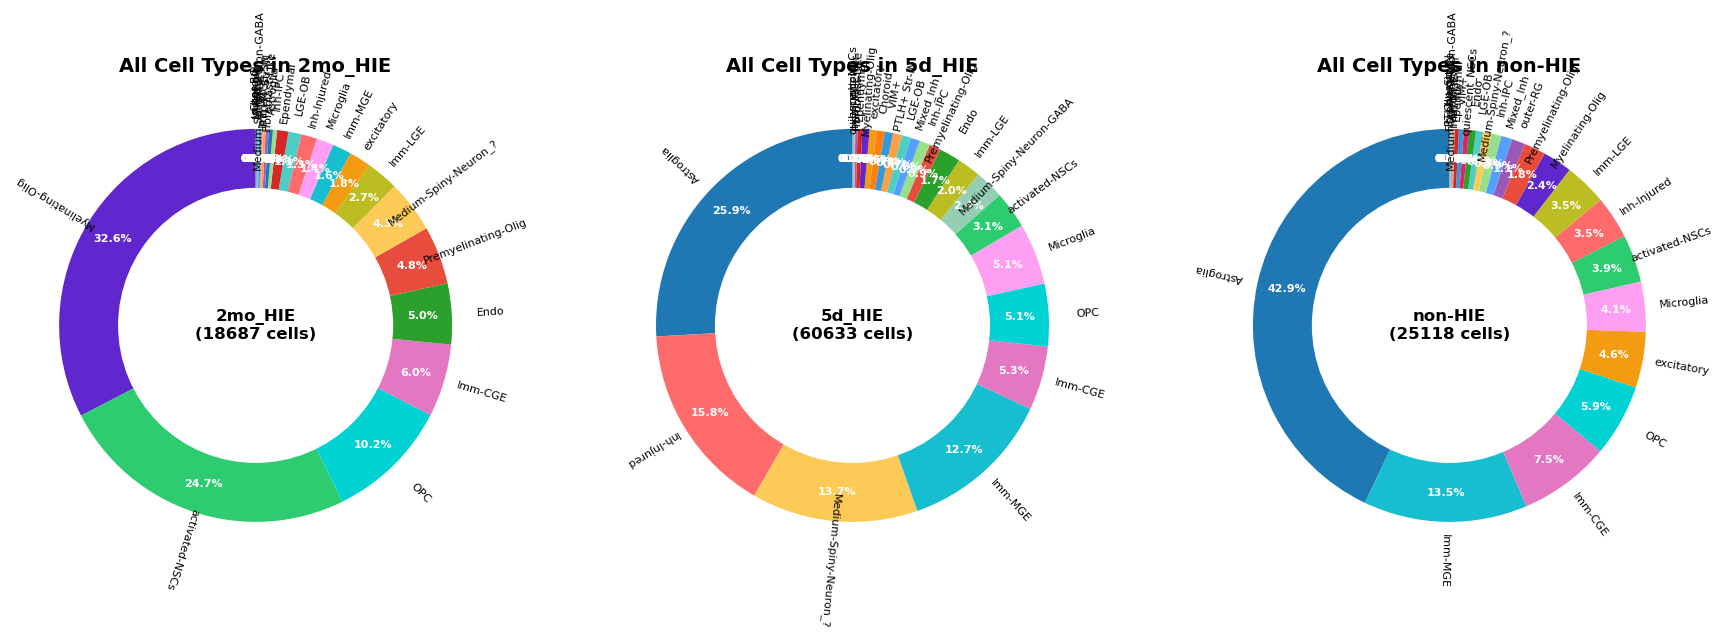

In [66]:
# =============================================================================
# DONUTS VISUALIZATIONS - ALL CELL TYPES
# =============================================================================

print("\n" + "="*80)
print("CREATING DONUTS CHARTS - ALL CELL TYPES")
print("="*80)

# Individual donut charts for each condition (showing all cell types)
if 'class' in adata.obs.columns and 'condition' in adata.obs.columns:
    # Use ALL data (no filtering)
    print(f"Total cells: {len(adata)} cells")
    print(f"Available cell types: {adata.obs['class'].nunique()} unique types")
    print(f"Available conditions: {adata.obs['condition'].nunique()} unique conditions")
    
    # Get unique cell types and conditions
    unique_cell_types = sorted(adata.obs['class'].unique())
    conditions = sorted(adata.obs['condition'].unique())
    
    # Define a darker color palette for cell types (NO LIGHT COLORS)
    dark_colors = [
        '#1f77b4',  # Dark blue
        '#ff7f0e',  # Dark orange
        '#2ca02c',  # Dark green
        '#d62728',  # Dark red
        '#9467bd',  # Dark purple
        '#e377c2',  # Dark pink
        '#bcbd22',  # Dark olive
        '#17becf',  # Dark cyan
        '#ff9896',  # Dark coral
        '#98df8a',  # Dark light green
        '#ff6b6b',  # Bright red
        '#4ecdc4',  # Teal
        '#45b7d1',  # Sky blue
        '#96ceb4',  # Mint green
        '#feca57',  # Golden yellow
        '#ff9ff3',  # Hot pink
        '#54a0ff',  # Electric blue
        '#5f27cd',  # Deep purple
        '#00d2d3',  # Cyan
        '#ff9f43',  # Orange
        '#e74c3c',  # Dark red
        '#3498db',  # Dark blue
        '#2ecc71',  # Dark green
        '#f39c12',  # Dark orange
        '#9b59b6',  # Dark purple
        '#e91e63',  # Dark pink
        '#00bcd4',  # Dark cyan
        '#795548',  # Dark brown
        '#607d8b',  # Dark blue grey
        '#ff5722'   # Deep orange
    ]
    
    # Create color mapping for cell types
    cell_type_color_map = {cell_type: dark_colors[i % len(dark_colors)] 
                          for i, cell_type in enumerate(unique_cell_types)}
    
    # Calculate grid layout for subplots
    n_conditions = len(conditions)
    n_cols = min(3, n_conditions)  # Max 3 columns
    n_rows = (n_conditions + n_cols - 1) // n_cols
    
    # Create figure with subplots for all conditions
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 6*n_rows))
    
    # Fix axes handling for different cases
    if n_conditions == 1:
        axes = [axes]  # Single subplot
    elif n_rows == 1 and n_cols > 1:
        axes = axes if hasattr(axes, '__len__') else [axes]  # Row of subplots
    else:
        axes = axes.flatten()  # Grid of subplots
    
    # Create donut chart for each condition
    for i, condition in enumerate(conditions):
        if i < len(axes):
            # Filter data for this specific condition
            condition_data = adata[adata.obs['condition'] == condition]
            cell_type_counts = condition_data.obs['class'].value_counts()
            
            # Get colors for this condition's cell types
            colors = [cell_type_color_map[cell_type] for cell_type in cell_type_counts.index]
            
            # Create donut chart (no labels yet)
            wedges, texts, autotexts = axes[i].pie(
                cell_type_counts.values, 
                labels=None,
                autopct='%1.1f%%',
                startangle=90,
                pctdistance=0.85,
                colors=colors
            )
            
            # Add donut labels manually, rotated along arc
            for w, label in zip(wedges, cell_type_counts.index):
                angle = (w.theta2 + w.theta1) / 2.0   # midpoint angle of wedge
                x = np.cos(np.deg2rad(angle))
                y = np.sin(np.deg2rad(angle))
                axes[i].text(
                    1.2*x, 1.2*y, label,
                    ha='center', va='center',
                    rotation=angle, rotation_mode='anchor',
                    fontsize=8
                )
            
            # Create donut effect by adding a white circle in the center
            centre_circle = plt.Circle((0,0), 0.70, fc='white')
            axes[i].add_artist(centre_circle)
            
            # Add condition name and total count in the center
            axes[i].text(0, 0, f'{condition}\n({len(condition_data)} cells)', 
                       ha='center', va='center', fontsize=12, fontweight='bold')
            
            axes[i].set_title(f'All Cell Types in {condition}', fontsize=14, fontweight='bold')
            
            # Adjust text properties for percentages
            for autotext in autotexts:
                autotext.set_color('white')
                autotext.set_fontweight('bold')
                autotext.set_fontsize(8)
    
    # Hide unused subplots
    for i in range(n_conditions, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f"{prefix}_all_cell_types_donuts.png", dpi=300, bbox_inches='tight')
    print(f"✓ All cell types donut charts saved as '{prefix}_all_cell_types_donuts.png'")
    plt.show()  # Display in Jupyter notebook
    plt.close()

else:
    print("⚠️ Required columns 'class' or 'condition' not found in metadata")


CREATING DONUTS CHARTS
Total cells: 104438 cells
Available cell types: 26 unique types
Available conditions: 3 unique conditions
✓ All cell types donut charts saved as 'hypoxia_anndata_annotated_all_cell_types_donuts.png'


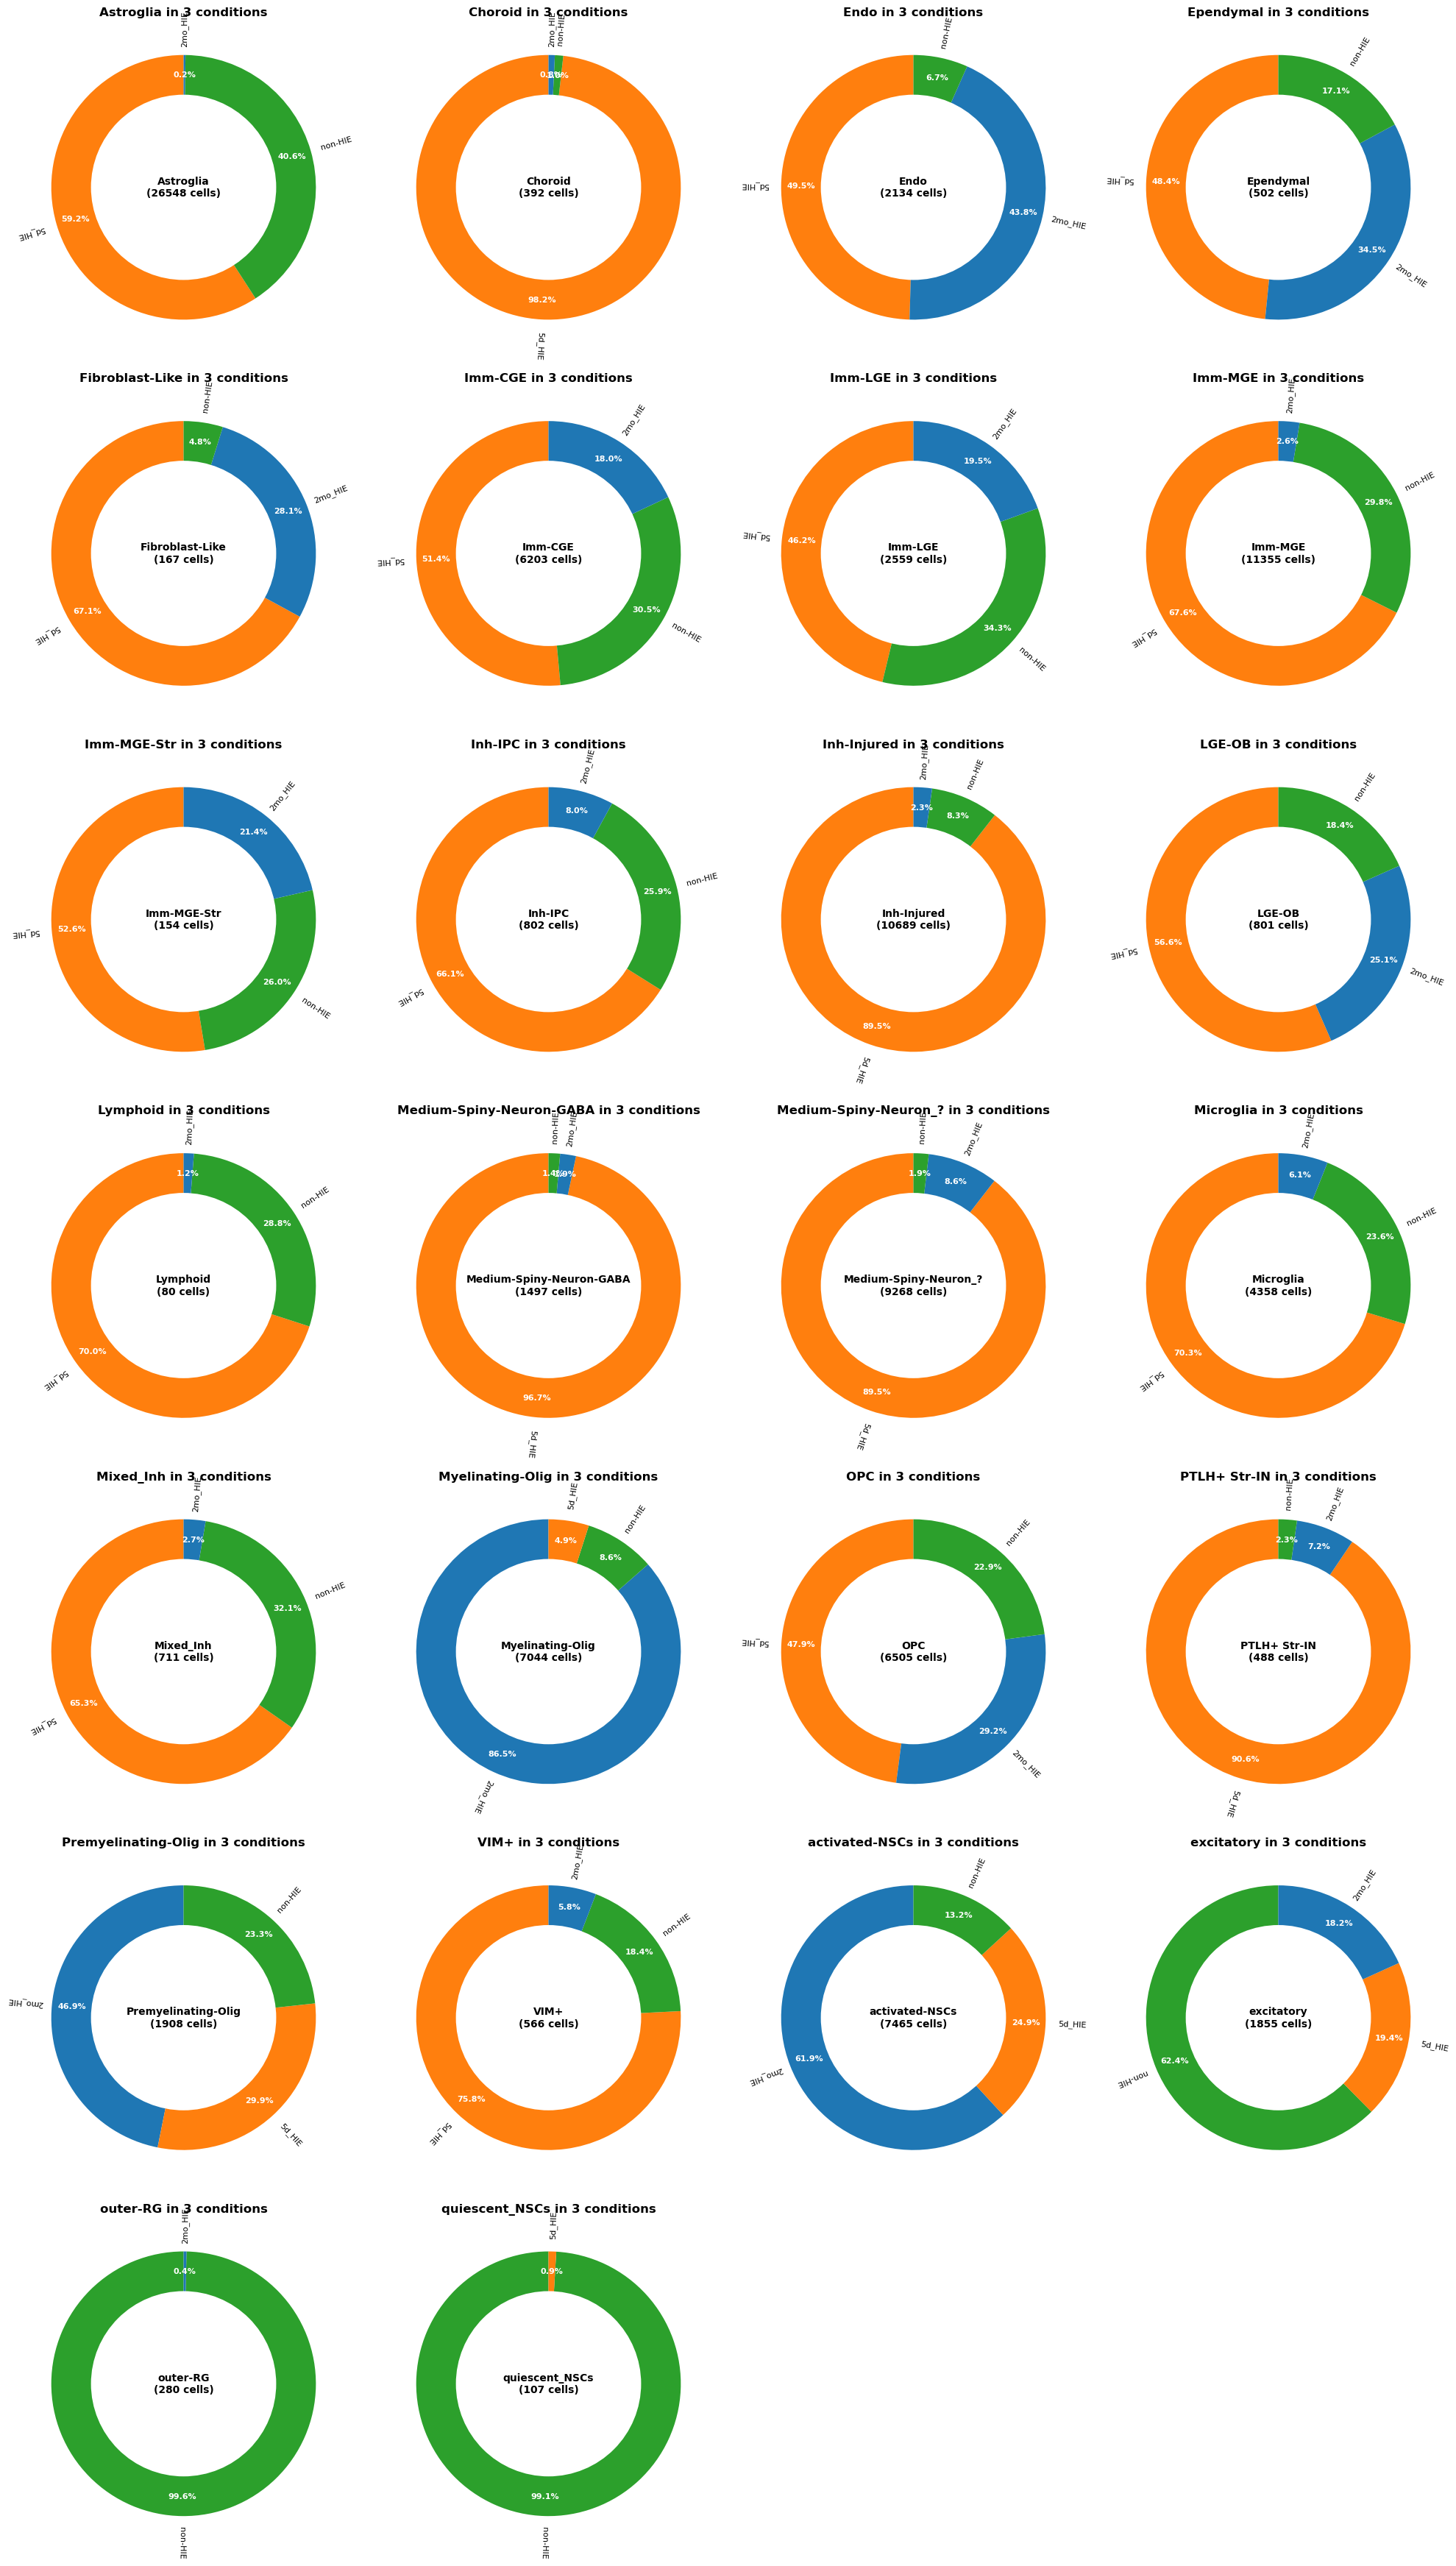

In [67]:
# =============================================================================
# DONUTS VISUALIZATIONS - ALL CELL TYPES
# =============================================================================

print("\n" + "="*80)
print("CREATING DONUTS CHARTS")
print("="*80)

# Individual donut charts for each cell type (showing condition distribution)
if 'class' in adata.obs.columns and 'condition' in adata.obs.columns:
    # Use ALL data (no filtering)
    print(f"Total cells: {len(adata)} cells")
    print(f"Available cell types: {adata.obs['class'].nunique()} unique types")
    print(f"Available conditions: {adata.obs['condition'].nunique()} unique conditions")
    
    # Get unique cell types and conditions
    unique_cell_types = sorted(adata.obs['class'].unique())
    conditions = sorted(adata.obs['condition'].unique())
    
    # Define a darker color palette for conditions
    dark_colors = [
        '#1f77b4',  # Dark blue
        '#ff7f0e',  # Dark orange
        '#2ca02c',  # Dark green
        '#d62728',  # Dark red
        '#9467bd',  # Dark purple
        '#8c564b',  # Dark brown
        '#e377c2',  # Dark pink
        '#7f7f7f',  # Dark gray
        '#bcbd22',  # Dark olive
        '#17becf',  # Dark cyan
        '#ff9896',  # Dark coral
        '#98df8a'   # Dark light green
    ]
    
    # Create color mapping for conditions
    condition_color_map = {condition: dark_colors[i % len(dark_colors)] 
                          for i, condition in enumerate(conditions)}
    
    # Calculate grid layout for subplots
    n_cell_types = len(unique_cell_types)
    n_cols = min(4, n_cell_types)  # Max 4 columns
    n_rows = (n_cell_types + n_cols - 1) // n_cols
    
    # Create figure with subplots for all cell types
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
    if n_cell_types == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes if isinstance(axes, list) else [axes]
    else:
        axes = axes.flatten()
    
    # Create donut chart for each cell type
    for i, cell_type in enumerate(unique_cell_types):
        if i < len(axes):
            # Filter data for this specific cell type
            cell_type_data = adata[adata.obs['class'] == cell_type]
            condition_counts = cell_type_data.obs['condition'].value_counts()
            
            # Get colors for this cell type's conditions
            colors = [condition_color_map[condition] for condition in condition_counts.index]
            
            # Create donut chart (no labels yet)
            wedges, texts, autotexts = axes[i].pie(
                condition_counts.values, 
                labels=None,
                autopct='%1.1f%%',
                startangle=90,
                pctdistance=0.85,
                colors=colors
            )
            
            # Add donut labels manually, rotated along arc
            for w, label in zip(wedges, condition_counts.index):
                angle = (w.theta2 + w.theta1) / 2.0   # midpoint angle of wedge
                x = np.cos(np.deg2rad(angle))
                y = np.sin(np.deg2rad(angle))
                axes[i].text(
                    1.2*x, 1.2*y, label,
                    ha='center', va='center',
                    rotation=angle, rotation_mode='anchor',
                    fontsize=8
                )
            
            # Create donut effect by adding a white circle in the center
            centre_circle = plt.Circle((0,0), 0.70, fc='white')
            axes[i].add_artist(centre_circle)
            
            # Add cell type name and total count in the center
            axes[i].text(0, 0, f'{cell_type}\n({len(cell_type_data)} cells)', 
                       ha='center', va='center', fontsize=10, fontweight='bold')
            
            axes[i].set_title(f'{cell_type} in 3 conditions', fontsize=12, fontweight='bold')
            
            # Adjust text properties for percentages
            for autotext in autotexts:
                autotext.set_color('white')
                autotext.set_fontweight('bold')
                autotext.set_fontsize(8)
    
    # Hide unused subplots
    for i in range(n_cell_types, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f"{prefix}_all_cell_types_donuts.png", dpi=300, bbox_inches='tight')
    print(f"✓ All cell types donut charts saved as '{prefix}_all_cell_types_donuts.png'")
    plt.show()  # Display in Jupyter notebook
    plt.close()
    



CREATING HORIZONTAL BARPLOTS
Filtered to 79024 cells with target cell types
Available cell types in filtered data: ['Inh-Injured', 'Imm-CGE', 'excitatory', 'Myelinating-Olig', 'Premyelinating-Olig', 'Imm-MGE', 'OPC', 'Imm-LGE', 'Astroglia', 'Microglia']
Categories (10, object): ['Astroglia', 'Imm-CGE', 'Imm-LGE', 'Imm-MGE', ..., 'Myelinating-Olig', 'OPC', 'Premyelinating-Olig', 'excitatory']
✓ Filtered cell types panel saved as 'hypoxia_anndata_annotated_filtered_cell_types_panel.png'


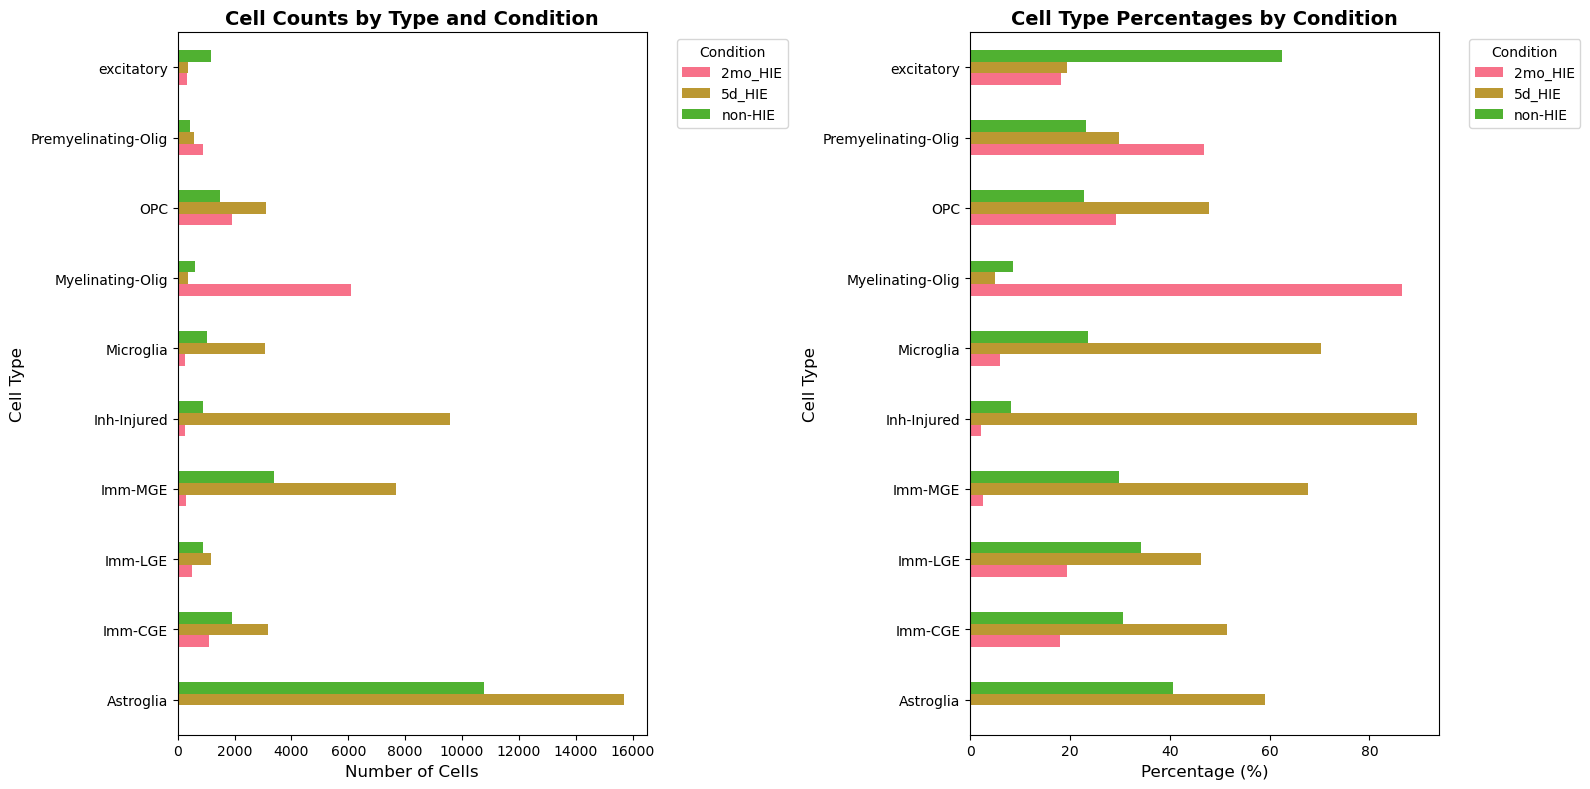

In [71]:
# =============================================================================
# BARPLOT VISUALIZATIONS
# =============================================================================

print("\n" + "="*80)
print("CREATING HORIZONTAL BARPLOTS")
print("="*80)

# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

# Filtered Cell Types (Counts and Percentages)
if 'class' in adata.obs.columns and 'condition' in adata.obs.columns:
    # Define the specific cell types to show
    target_cell_types = [
        'Astroglia', 'Imm-CGE', 'Imm-LGE', 'Imm-MGE', 'Ing-IPC', 'Inh-Injured', 
        'Microglia', 'Myelinating-Olig', 'OPC', 'Premyelinating-Olig', 
        'activated-NSC', 'excitatory'
    ]
    
    # Filter data for only the target cell types
    filtered_adata = adata[adata.obs['class'].isin(target_cell_types)].copy()
    
    if len(filtered_adata) > 0:
        print(f"Filtered to {len(filtered_adata)} cells with target cell types")
        print(f"Available cell types in filtered data: {filtered_adata.obs['class'].unique()}")
        
        fig1 = plt.figure(figsize=(16, 8))
        
        # 1. Cell counts - Horizontal barplot
        ax1 = plt.subplot(1, 2, 1)
        counts_table_filtered = pd.crosstab(filtered_adata.obs['class'], filtered_adata.obs['condition'])
        counts_table_filtered.plot(kind='barh', ax=ax1)
        ax1.set_title('Cell Counts by Type and Condition', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Number of Cells', fontsize=12)
        ax1.set_ylabel('Cell Type', fontsize=12)
        ax1.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
        ax1.tick_params(axis='both', labelsize=10)
        plt.tight_layout()

        # 2. Cell percentages - Horizontal barplot
        ax2 = plt.subplot(1, 2, 2)
        percentages_table_filtered = pd.crosstab(filtered_adata.obs['class'], filtered_adata.obs['condition'], normalize='index') * 100
        percentages_table_filtered.plot(kind='barh', ax=ax2)
        ax2.set_title('Cell Type Percentages by Condition', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Percentage (%)', fontsize=12)
        ax2.set_ylabel('Cell Type', fontsize=12)
        ax2.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
        ax2.tick_params(axis='both', labelsize=10)
        plt.tight_layout()

        # Save Panel 1
        plt.tight_layout()
        plt.savefig(f"{prefix}_filtered_cell_types_panel.png", dpi=300, bbox_inches='tight')
        print(f"✓ Filtered cell types panel saved as '{prefix}_filtered_cell_types_panel.png'")
        plt.show()  # Display in Jupyter notebook
        plt.close()
    else:
        print("⚠️ No cells found with the specified cell types")



CREATING DONUTS CHARTS
Filtered to 79024 cells with target cell types
Available cell types in filtered data: ['Inh-Injured', 'Imm-CGE', 'excitatory', 'Myelinating-Olig', 'Premyelinating-Olig', 'Imm-MGE', 'OPC', 'Imm-LGE', 'Astroglia', 'Microglia']
Categories (10, object): ['Astroglia', 'Imm-CGE', 'Imm-LGE', 'Imm-MGE', ..., 'Myelinating-Olig', 'OPC', 'Premyelinating-Olig', 'excitatory']
✓ All donut charts in same row saved as 'hypoxia_anndata_annotated_donuts_same_row.png'


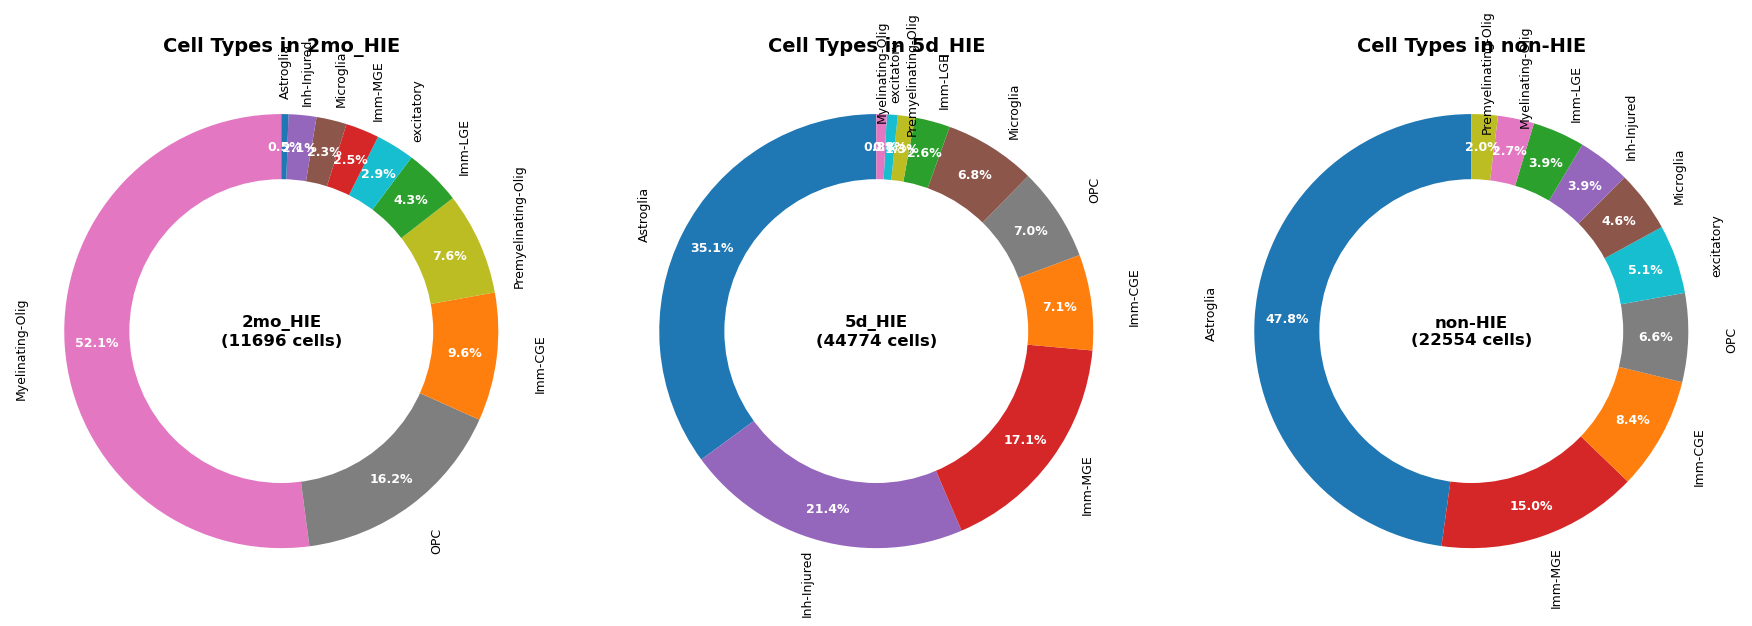

In [72]:
# =============================================================================
# DONUTS VISUALIZATIONS
# =============================================================================

print("\n" + "="*80)
print("CREATING DONUTS CHARTS")
print("="*80)

# Individual donut charts for each condition
if 'class' in adata.obs.columns and 'condition' in adata.obs.columns:
    # Define the specific cell types to show
    target_cell_types = [
        'Astroglia', 'Imm-CGE', 'Imm-LGE', 'Imm-MGE', 'Ing-IPC', 'Inh-Injured', 
        'Microglia', 'Myelinating-Olig', 'OPC', 'Premyelinating-Olig', 
        'activated-NSC', 'excitatory'
    ]
    
    # Filter data for only the target cell types
    filtered_adata = adata[adata.obs['class'].isin(target_cell_types)].copy()
    
    if len(filtered_adata) > 0:
        print(f"Filtered to {len(filtered_adata)} cells with target cell types")
        print(f"Available cell types in filtered data: {filtered_adata.obs['class'].unique()}")
        
        # Create a consistent color mapping for all cell types with darker colors
        unique_cell_types = sorted(filtered_adata.obs['class'].unique())
        
        # Define a darker color palette
        dark_colors = [
            '#1f77b4',  # Dark blue
            '#ff7f0e',  # Dark orange
            '#2ca02c',  # Dark green
            '#d62728',  # Dark red
            '#9467bd',  # Dark purple
            '#8c564b',  # Dark brown
            '#e377c2',  # Dark pink
            '#7f7f7f',  # Dark gray
            '#bcbd22',  # Dark olive
            '#17becf',  # Dark cyan
            '#ff9896',  # Dark coral
            '#98df8a'   # Dark light green
        ]
        
        # Create color mapping with darker colors
        color_map = {cell_type: dark_colors[i % len(dark_colors)] 
                    for i, cell_type in enumerate(unique_cell_types)}
        
        conditions = filtered_adata.obs['condition'].unique()
        n_conditions = len(conditions)
        
        # Create figure with all donuts in the same row
        fig, axes = plt.subplots(1, n_conditions, figsize=(6*n_conditions, 6))
        if n_conditions == 1:
            axes = [axes]  # Make it a list for consistency
        
        # Create donut chart for each condition
        for i, condition in enumerate(conditions):
            condition_data = filtered_adata[filtered_adata.obs['condition'] == condition]
            cell_counts = condition_data.obs['class'].value_counts()
            
            # Get colors for this condition's cell types
            colors = [color_map[cell_type] for cell_type in cell_counts.index]
            
            # Create donut chart (no labels yet)
            wedges, texts, autotexts = axes[i].pie(
                cell_counts.values, 
                labels=None,  # Labels handled manually
                autopct='%1.1f%%',
                startangle=90,
                pctdistance=0.85,
                colors=colors
            )
            
            # Add donut labels manually, rotated at 90 degrees
            for w, label in zip(wedges, cell_counts.index):
                angle = (w.theta2 + w.theta1) / 2.0   # midpoint angle of wedge
                x = np.cos(np.deg2rad(angle))
                y = np.sin(np.deg2rad(angle))
                axes[i].text(
                    1.2*x, 1.2*y, label,
                    ha='center', va='center',
                    rotation=90,  # Fixed 90 degrees rotation
                    rotation_mode='anchor',
                    fontsize=9
                )
            
            # Create donut effect by adding a white circle in the center
            centre_circle = plt.Circle((0,0), 0.70, fc='white')
            axes[i].add_artist(centre_circle)
            
            # Add condition name and total count in the center
            axes[i].text(0, 0, f'{condition}\n({len(condition_data)} cells)', 
                       ha='center', va='center', fontsize=12, fontweight='bold')
            
            axes[i].set_title(f'Cell Types in {condition}', fontsize=14, fontweight='bold')
            
            # Adjust text properties for percentages
            for autotext in autotexts:
                autotext.set_color('white')
                autotext.set_fontweight('bold')
                autotext.set_fontsize(9)
        
        plt.tight_layout()
        plt.savefig(f"{prefix}_donuts_same_row.png", dpi=300, bbox_inches='tight')
        print(f"✓ All donut charts in same row saved as '{prefix}_donuts_same_row.png'")
        plt.show()  # Display in Jupyter notebook
        plt.close()
    else:
        print("⚠️ No cells found with the specified cell types")
else:
    print("⚠️ Required columns 'class' or 'condition' not found in metadata")

In [54]:
# the data was save in : 
# save adata4 to .h5ad
# out_h5ad = f"{prefix}.adata4_geneformer.h5ad" if 'prefix' in locals() else "adata4.h5ad"
# adata4.write(out_h5ad)  # or: adata4.write(out_h5ad, compression="gzip")
# print("saved:", out_h5ad)

In [73]:
# double check : 

# Table 1: Raw cell counts
print("\n1. RAW CELL COUNTS TABLE")
print("-" * 50)
if 'class' in adata4.obs.columns and 'condition' in adata4.obs.columns:
    # Create crosstab with class as rows and condition as columns
    counts_table = pd.crosstab(adata4.obs['class'], adata4.obs['condition'], margins=True)
    print("Cell Type (rows) vs Condition (columns) - Raw Counts:")
    print(counts_table)
    
    # Save to CSV
    counts_table.to_csv(f"{prefix}_cell_type_counts_table.+.csv")
    print(f"\n✓ Raw counts table saved as '{prefix}_cell_type_counts_table.+.csv'")


1. RAW CELL COUNTS TABLE
--------------------------------------------------
Cell Type (rows) vs Condition (columns) - Raw Counts:
condition                 2mo_HIE  5d_HIE  non-HIE     All
class                                                     
Astroglia                      62   15704    10782   26548
Choroid                         3     385        4     392
Endo                          935    1057      142    2134
Ependymal                     173     243       86     502
Fibroblast-Like                47     112        8     167
Imm-CGE                      1117    3191     1895    6203
Imm-LGE                       498    1183      878    2559
Imm-MGE                       292    7677     3386   11355
Imm-MGE-Str                    33      81       40     154
Inh-IPC                        64     530      208     802
Inh-Injured                   242    9562      885   10689
LGE-OB                        201     453      147     801
Lymphoid                        1      56  

In [74]:
# Table 2: Percentages
print("\n2. PERCENTAGES TABLE")
print("-" * 50)
if 'class' in adata4.obs.columns and 'condition' in adata4.obs.columns:
    # Create crosstab with percentages
    percentages_table = pd.crosstab(adata4.obs['class'], adata4.obs['condition'], normalize='index') * 100
    percentages_table = percentages_table.round(1)
    
    # Add margins (total row)
    total_row = percentages_table.sum(axis=1)
    percentages_table['Total'] = total_row
    percentages_table.loc['Total'] = percentages_table.sum(axis=0)
    
    print("Cell Type (rows) vs Condition (columns) - Percentages:")
    print(percentages_table)
    
    # Save to CSV
    percentages_table.to_csv(f"{prefix}_cell_type_percentages_table.+.csv")
    print(f"\n✓ Percentages table saved as '{prefix}_cell_type_percentages_table.+.csv'")



2. PERCENTAGES TABLE
--------------------------------------------------
Cell Type (rows) vs Condition (columns) - Percentages:
condition                 2mo_HIE  5d_HIE  non-HIE   Total
class                                                     
Astroglia                     0.2    59.2     40.6   100.0
Choroid                       0.8    98.2      1.0   100.0
Endo                         43.8    49.5      6.7   100.0
Ependymal                    34.5    48.4     17.1   100.0
Fibroblast-Like              28.1    67.1      4.8   100.0
Imm-CGE                      18.0    51.4     30.5    99.9
Imm-LGE                      19.5    46.2     34.3   100.0
Imm-MGE                       2.6    67.6     29.8   100.0
Imm-MGE-Str                  21.4    52.6     26.0   100.0
Inh-IPC                       8.0    66.1     25.9   100.0
Inh-Injured                   2.3    89.5      8.3   100.1
LGE-OB                       25.1    56.6     18.4   100.1
Lymphoid                      1.2    70.0     

In [64]:
# Create a h5ad object for each cell class

In [79]:
# Save individual h5ad files for each cell type
print("\n" + "="*80)
print("SAVING INDIVIDUAL H5AD FILES FOR EACH CELL TYPE")
print("="*80)

if 'adata4' in locals() and 'class' in adata4.obs.columns:
    # Get unique cell types
    unique_cell_types = adata4.obs['class'].unique()
    print(f"Found {len(unique_cell_types)} unique cell types")
    print(f"Cell types: {sorted(unique_cell_types)}")
    
    # Save individual h5ad file for each cell type
    for cell_type in unique_cell_types:
        # Filter data for this specific cell type
        cell_type_data = adata4[adata4.obs['class'] == cell_type].copy()
        
        # Create filename with prefix and cell type
        filename = f"{prefix}.adata5_geneformer.{cell_type}.h5ad"
        
        # Save the filtered data
        cell_type_data.write(filename)
        
        print(f"✓ Saved {cell_type}: {len(cell_type_data)} cells × {cell_type_data.n_vars} genes → {filename}")
    
    print(f"\n✓ Successfully saved {len(unique_cell_types)} individual h5ad files")
    print(f"All files saved with prefix: {prefix}")
    
else:
    if 'adata4' not in locals():
        print("⚠️ adata4 object not found. Please make sure it exists.")
    else:
        print("⚠️ 'class' column not found in adata4.obs")


SAVING INDIVIDUAL H5AD FILES FOR EACH CELL TYPE
Found 26 unique cell types
Cell types: ['Astroglia', 'Choroid', 'Endo', 'Ependymal', 'Fibroblast-Like', 'Imm-CGE', 'Imm-LGE', 'Imm-MGE', 'Imm-MGE-Str', 'Inh-IPC', 'Inh-Injured', 'LGE-OB', 'Lymphoid', 'Medium-Spiny-Neuron-GABA', 'Medium-Spiny-Neuron_?', 'Microglia', 'Mixed_Inh', 'Myelinating-Olig', 'OPC', 'PTLH+ Str-IN', 'Premyelinating-Olig', 'VIM+', 'activated-NSCs', 'excitatory', 'outer-RG', 'quiescent_NSCs']
✓ Saved Inh-Injured: 10689 cells × 21862 genes → hypoxia_anndata_annotated.adata5_geneformer.Inh-Injured.h5ad
✓ Saved Medium-Spiny-Neuron_?: 9268 cells × 21862 genes → hypoxia_anndata_annotated.adata5_geneformer.Medium-Spiny-Neuron_?.h5ad
✓ Saved Imm-CGE: 6203 cells × 21862 genes → hypoxia_anndata_annotated.adata5_geneformer.Imm-CGE.h5ad
✓ Saved PTLH+ Str-IN: 488 cells × 21862 genes → hypoxia_anndata_annotated.adata5_geneformer.PTLH+ Str-IN.h5ad
✓ Saved excitatory: 1855 cells × 21862 genes → hypoxia_anndata_annotated.adata5_genefo

In [80]:
# Save individual h5ad files for each broad class
print("\n" + "="*80)
print("SAVING INDIVIDUAL H5AD FILES FOR EACH BROAD CLASS")
print("="*80)

if 'adata4' in locals() and 'broad_class' in adata4.obs.columns:
    # Get unique broad classes
    unique_broad_classes = adata4.obs['broad_class'].unique()
    print(f"Found {len(unique_broad_classes)} unique broad classes")
    print(f"Broad classes: {sorted(unique_broad_classes)}")
    
    # Save individual h5ad file for each broad class
    for broad_class in unique_broad_classes:
        # Filter data for this specific broad class
        broad_class_data = adata4[adata4.obs['broad_class'] == broad_class].copy()
        
        # Create filename with prefix and broad class
        filename = f"{prefix}.adata5_geneformer.{broad_class}.h5ad"
        
        # Save the filtered data
        broad_class_data.write(filename)
        
        print(f"✓ Saved {broad_class}: {len(broad_class_data)} cells × {broad_class_data.n_vars} genes → {filename}")
    
    print(f"\n✓ Successfully saved {len(unique_broad_classes)} individual h5ad files")
    print(f"All files saved with prefix: {prefix}")
    
else:
    if 'adata4' not in locals():
        print("⚠️ adata4 object not found. Please make sure it exists.")
    else:
        print("⚠️ 'broad_class' column not found in adata4.obs")


SAVING INDIVIDUAL H5AD FILES FOR EACH BROAD CLASS
Found 3 unique broad classes
Broad classes: ['Excitatory', 'Inhibitory', 'Non-Neuronal']
✓ Saved Non-Neuronal: 79510 cells × 21862 genes → hypoxia_anndata_annotated.adata5_geneformer.Non-Neuronal.h5ad
✓ Saved Inhibitory: 23073 cells × 21862 genes → hypoxia_anndata_annotated.adata5_geneformer.Inhibitory.h5ad
✓ Saved Excitatory: 1855 cells × 21862 genes → hypoxia_anndata_annotated.adata5_geneformer.Excitatory.h5ad

✓ Successfully saved 3 individual h5ad files
All files saved with prefix: hypoxia_anndata_annotated


In [81]:
# Print metadata columns for cells and genes
print("\n" + "="*80)
print("METADATA COLUMNS INFORMATION")
print("="*80)

# Print cell metadata columns
print("\nCELL METADATA (.obs):")
print("-" * 40)
if hasattr(adata, 'obs') and not adata.obs.empty:
    print(f"Number of cells: {adata.n_obs}")
    print(f"Number of columns: {len(adata.obs.columns)}")
    print(f"Columns: {list(adata.obs.columns)}")
    print("\nFirst few rows:")
    print(adata.obs.head())
else:
    print("No cell metadata found")

# Print gene metadata columns
print("\nGENE METADATA (.var):")
print("-" * 40)
if hasattr(adata, 'var') and not adata.var.empty:
    print(f"Number of genes: {adata.n_vars}")
    print(f"Number of columns: {len(adata.var.columns)}")
    print(f"Columns: {list(adata.var.columns)}")
    print("\nFirst few rows:")
    print(adata.var.head())
else:
    print("No gene metadata found")

# Print additional information
print("\nADDITIONAL INFORMATION:")
print("-" * 40)
print(f"Dataset shape: {adata.shape}")
print(f"Layers: {list(adata.layers.keys()) if adata.layers else 'None'}")
print(f"Embeddings (.obsm): {list(adata.obsm.keys()) if adata.obsm else 'None'}")
print(f"Gene annotations (.varm): {list(adata.varm.keys()) if adata.varm else 'None'}")


METADATA COLUMNS INFORMATION

CELL METADATA (.obs):
----------------------------------------
Number of cells: 104438
Number of columns: 30
Columns: ['sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'condition', '_scvi_batch', '_scvi_labels', 'leiden', 'merged_labels', 'class', 'broad_class', 'n_counts', 'counts']

First few rows:
                       sample  n_genes_by_counts  log1p_n_genes_by_counts  \
TCAAGACCACAAAGCG-1  AP4765_03              12290                 9.416623   
CTCCACATCGCCACTT-1  AP4765_03              11499                 9.350102   
CTTAGGATCTTTCCAA-1  AP4765_0

In [82]:
# Check if "label" is present in column names
print("\n" + "="*80)
print("CHECKING FOR 'LABEL' IN COLUMN NAMES")
print("="*80)

# Check in cell metadata columns
print("\nCELL METADATA (.obs) - Checking for 'label':")
print("-" * 50)
if hasattr(adata, 'obs') and not adata.obs.empty:
    cell_columns = list(adata.obs.columns)
    label_columns = [col for col in cell_columns if 'label' in col.lower()]
    
    if label_columns:
        print(f"✓ Found {len(label_columns)} columns containing 'label':")
        for col in label_columns:
            print(f"  - {col}")
    else:
        print("✗ No columns containing 'label' found in cell metadata")
    
    print(f"\nAll cell metadata columns: {cell_columns}")
else:
    print("No cell metadata found")

# Check in gene metadata columns
print("\nGENE METADATA (.var) - Checking for 'label':")
print("-" * 50)
if hasattr(adata, 'var') and not adata.var.empty:
    gene_columns = list(adata.var.columns)
    label_columns = [col for col in gene_columns if 'label' in col.lower()]
    
    if label_columns:
        print(f"✓ Found {len(label_columns)} columns containing 'label':")
        for col in label_columns:
            print(f"  - {col}")
    else:
        print("✗ No columns containing 'label' found in gene metadata")
    
    print(f"\nAll gene metadata columns: {gene_columns}")
else:
    print("No gene metadata found")

# Check in all available metadata
print("\nSUMMARY:")
print("-" * 50)
all_columns = []
if hasattr(adata, 'obs') and not adata.obs.empty:
    all_columns.extend(adata.obs.columns)
if hasattr(adata, 'var') and not adata.var.empty:
    all_columns.extend(adata.var.columns)

all_label_columns = [col for col in all_columns if 'label' in col.lower()]

if all_label_columns:
    print(f"✓ Total columns containing 'label': {len(all_label_columns)}")
    print(f"Columns: {all_label_columns}")
else:
    print("✗ No columns containing 'label' found in any metadata")


CHECKING FOR 'LABEL' IN COLUMN NAMES

CELL METADATA (.obs) - Checking for 'label':
--------------------------------------------------
✓ Found 2 columns containing 'label':
  - _scvi_labels
  - merged_labels

All cell metadata columns: ['sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'condition', '_scvi_batch', '_scvi_labels', 'leiden', 'merged_labels', 'class', 'broad_class', 'n_counts', 'counts']

GENE METADATA (.var) - Checking for 'label':
--------------------------------------------------
✗ No columns containing 'label' found in gene metadata

All gene metadata columns: ['mt', 'r